In [1]:
_MERKZETTEL = {}


def merke(schluessel, wert):
    """Haelt ein Ergebnis fuer den Fliesstext fest und gibt es zurueck."""
    _MERKZETTEL[schluessel] = wert
    return wert

# Assoziationsanalyse: Welche Wege gehören zusammen?

**Verfahren:** Assoziationsanalyse (unüberwacht — das Ergebnis sind Regeln, keine Zahlen und keine Gruppen)  |  **Geschäftsfrage:** Zwischen welchen Stationen gibt es systematische Ströme, und wann?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/05_Assoziation_Wege_im_Netz.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Phase</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Leitfrage</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Business Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Was ist die Geschäftsfrage — und woran messen wir Erfolg?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Data Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welche Daten haben wir, und taugen sie für diese Frage?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Data Preparation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">4</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Modeling</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Welches Verfahren, welche Einstellungen, wie geprüft?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">5</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Evaluation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">6</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Deployment</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wie kommt das Modell in den Betrieb — und was passiert danach?</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

> ### Kurzfassung
>
> **Fragestellung.** Gibt es Verbindungen, die innerhalb desselben Zeitfensters häufiger
> auftreten, als bei zufälliger Zielwahl zu erwarten wäre? Und sind diese Muster
> zeitlich stabil?
>
> **Vorgehen.** Gezählt statt trainiert: Support, Konfidenz und Lift ergeben sich aus
> drei Divisionen. Die Regeln werden in den ersten zwei Dritteln des Zeitraums gesucht;
> das letzte Drittel bleibt bis zur Bestätigung ungeöffnet.
>
> **Ergebnis.** Produkt A, die automatische Umverteilung, ist nicht freigegeben (Wirtschaftlichkeit nicht prüfbar).
> Ausschlaggebend dafür ist nicht die Qualität der Regeln: Fahrten, die mangels
> verfügbarem Rad nie zustande kamen, sind in diesen Daten nicht enthalten, und ohne sie
> ist der Nutzen einer Umverteilung nicht zu beziffern. Produkt B, der
> Dispositionshinweis, umfasst
> 6 von 11 geprüften Regeln. Gefordert war nicht ein
> Punktschätzer über 1,3, sondern die untere Grenze eines
> Tagesblock-Bootstraps — nur so lässt sich die Abhängigkeit von Fahrten desselben Tages
> berücksichtigen.
>
> **Status: analytisches Lehr-Gate bestanden — keine reale Betriebsfreigabe**
>
> **Was offen bleibt.** Die Hürde aus Phase 1 ist als Anteil an allen Warenkörben
> formuliert. Umgerechnet entspricht sie 0,66 Fahrten je Werktag —
> einer Größenordnung, in der keine Umsetzfahrt begonnen wird. Das Kriterium war damit
> auf der falschen Skala formuliert; verschoben wurde es dennoch nicht.

## Einordnung des Verfahrens

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Notebook</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Ergebnis des Verfahrens</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1 und 2</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">eine <strong>Vorhersage</strong> je Objekt (Dauer, Ausfallrisiko)</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">eine <strong>Gruppe</strong> je Objekt (Stationstyp, Kundensegment)</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>5</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Regeln über Zusammenhänge</strong> — keine Vorhersage, keine Gruppe</td></tr>
</tbody></table>
<div style="clear:both"></div>

Die Assoziationsanalyse stammt aus dem Handel und heißt dort **Warenkorbanalyse**:
Welche Artikel liegen zusammen im Einkaufswagen? Übertragen auf VeloCity ist **eine
Fahrt ein Warenkorb** — darin liegen Start, Ziel, Tageszeit, Wochentag und Radtyp. Die
Frage lautet: Was liegt regelmäßig zusammen im selben Korb?

Die drei Kennzahlen bestehen aus je einer Division und werden hier ohne Bibliothek
gerechnet.

> **Datengrundlage.** Die VeloCity-Daten sind **synthetisch**, erzeugt für diese
> Fallstudie. Verfahren und Entscheidungswege sind übertragbar; die Zahlen beschreiben
> kein reales Verkehrsaufkommen.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Die Disposition weiß, dass sie morgens umverteilen muss. Sie weiß nicht, **wohin**.

### Die Ausgangslage

Notebook 3 hat die **Typen** von Stationen bestimmt. Offen ist, **welche Station sich
zugunsten welcher anderen leert**. Die Frage lautet nicht mehr „wie viele Räder"
(Notebook 4), sondern **„von wo nach wo"**.

Eine Kreuztabelle Start × Ziel beantwortet sie nicht: Sie zeigt absolute Häufigkeiten,
und die größten Zahlen stehen dort, wo am meisten Betrieb ist. Der Hauptbahnhof steht
überall oben, weil er groß ist, nicht weil er besondere Beziehungen hat. Der **Lift**
rechnet diesen Größeneffekt heraus.

### Die drei Kennzahlen

Am Beispiel der Regel **{Brot} → {Butter}**:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Kennzahl</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Frage</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Rechnung</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Support</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wie oft kommt die Kombination überhaupt vor?</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Körbe mit Brot <em>und</em> Butter ÷ alle Körbe</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Konfidenz</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Wenn Brot drin ist — wie oft dann auch Butter?</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Körbe mit beidem ÷ Körbe mit Brot</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Lift</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Ist das mehr, als der Zufall hergäbe?</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Konfidenz ÷ Anteil aller Körbe mit Butter</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Lift = 1** bedeutet kein Zusammenhang, **Lift = 2** doppelt so häufig wie erwartet,
**Lift < 1** ein Meiden.

### Kontextbedingter Lift

Jede Fahrt hat einen **Kontext**: Werktag oder freier Tag, dazu eines von vier
Zeitfenstern. Die Ziele sind je nach Kontext unterschiedlich beliebt — der Campus ist
werktags früh häufiges Ziel, sonntags abends kaum. Ein Lift gegen den Anteil über
**alle** Fahrten misst deshalb zwei Dinge zugleich.

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Nenner der Division</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Was er misst</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">klassischer Lift</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Anteil des Ziels an <strong>allen</strong> Fahrten</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Zusammenhang <strong>und</strong> Kontexteffekt, vermischt</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>kontextbedingter Lift</strong> ← gewählt</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Anteil des Ziels <strong>im selben Kontext</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nur den Zusammenhang, bei gleichem Kontext</td></tr>
</tbody></table>
<div style="clear:both"></div>

Der Zähler ist in beiden Fällen derselbe. Für die supportstärkste Regel dieses Notebooks
— Werktag · früh (0-10) von „Juliuspromenade" nach „Grombühl Klinikum" — liegt der klassische Lift bei
**3,00**, der kontextbedingte bei **1,91**. Ab
hier wird ausschließlich der kontextbedingte Lift ausgewiesen; die Schwellen beziehen
sich auf ihn. Beide Werte stehen in Phase 4 nebeneinander.

### Erfolgskriterien

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Kriterium</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Schwelle</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Warum</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Support</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">mindestens 1 % der <strong>Warenkörbe</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Für eine Regel, die zwanzig Fahrten im Jahr betrifft, fährt kein Transporter</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>kontextbedingter Lift</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">mindestens 1,3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Darunter ist es Zufall oder schlicht Größe</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Ziel ist eine konkrete Station</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Start ≠ Ziel, und das Ziel ist keine freie Abstellung</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">eine Rundtour verschiebt kein Rad; „frei abgestellt" ist kein anfahrbarer Ort</td></tr>
</tbody></table>
<div style="clear:both"></div>

Kriterium 3 prüft ausschließlich die **technische Adressierbarkeit** und wird in Phase 5
als Code geprüft. Ob Menge, Bestand, Kapazität und Kosten eine Transporterfahrt
rechtfertigen, sagt es nicht. Kriterium 1 sortiert die meisten Regeln aus, darunter die
mit den höchsten Lift-Werten.

### Produkt A und Produkt B

Dieses Notebook kann zwei verschiedene Dinge abliefern. Beide Kriteriensätze stehen vor
der ersten Rechnung fest.

**Produkt A — automatische Umverteilung.** Der Transporter fährt, weil eine Regel es
sagt. Dafür kommt zu den drei Hürden eine vierte, wirtschaftliche:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Kriterium</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Schwelle</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>A4</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Der Wert der Fahrten, die eine Regel je Umsetzrunde betrifft, muss die Kosten dieser Runde übersteigen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">35 € je Runde gegen 2,20 € je Fahrt — <strong>beides gesetzte Szenarioannahmen</strong>, keine gemessenen Kosten</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Produkt B — Dispositionshinweis.** Kein Transportauftrag, sondern ein Satz in der
Dispositionsansicht, den ein Mensch bewertet:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Kriterium</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Warum</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B1</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Die Regel hält in einem <strong>Bestätigungszeitraum</strong>, den die Suche nicht gesehen hat</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Ein Muster aus dem Suchzeitraum ist eine Beschreibung, kein Befund</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B2</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Die Anzeige nennt die <strong>Größenordnung</strong> — Fahrten je Werktag — neben der Regel</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Ohne sie wird „Pendelstrom" als Transportauftrag gelesen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B3</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Kein automatischer Auftrag; die Entscheidung trifft ein Mensch</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Für die Automatik fehlt A4</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>B4</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Begleitende Auswertungen (Stationssalden, Abstell-Hotspots) tragen im Dateikopf und in der Ansicht das Wort <strong>explorativ</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Sie hatten nie vorab gesetzte Kriterien</td></tr>
</tbody></table>
<div style="clear:both"></div>

Ohne eigene Kriterien ließe sich der Dispositionshinweis weder freigeben noch ablehnen.
Er wird deshalb hier als eigenes Produkt definiert, nicht erst in Phase 6.

---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Was liegt in unseren Warenkörben, und wie häufig ist jedes Ding für sich?

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
  
# ─── DARSTELLUNG ────────────────────────────────────────────────────
# Farben und Helfer fuer Tabellen und interaktive Diagramme. Rein
# kosmetisch: Keine Zahl und kein Urteil dieses Notebooks haengt daran.
FARBE = {
    "akzent": "#2F2F2F", "akzent_hell": "#767676",
    "flaeche": "#FAFAFA", "flaeche_dunkel": "#EFEFEF",
    "linie": "#D8D8D8", "text": "#333333",
    "gut": "#4A4A4A", "warnung": "#8C2F39",
    "reihe": ['#2F2F2F', '#767676', '#8C2F39', '#A8A8A8', '#5A5A5A', '#C4C4C4'],
}


def stil(rahmen, balken=None, prozent=None):
    """Ergebnistabelle mit Balken in einer Spalte und linksbuendigem Kopf."""
    s = (rahmen.style
         .set_table_styles([
             {"selector": "th", "props": [("text-align", "left"),
              ("border-bottom", "2px solid " + FARBE["akzent"]),
              ("color", FARBE["akzent"]), ("padding", "6px 14px 6px 0")]},
             {"selector": "td", "props": [("text-align", "left"),
              ("border-bottom", "1px solid " + FARBE["linie"]),
              ("padding", "5px 14px 5px 0")]}])
         .hide(axis="index"))
    if balken:
        s = s.bar(subset=[balken], color=FARBE["akzent_hell"], vmin=0)
    if prozent:
        s = s.format({spalte: "{:.1%}" for spalte in prozent})
    return s


def interaktiv(fig, titel="", hoehe=420):
    """Zeigt ein Plotly-Diagramm — in Colab bedienbar, auf GitHub nicht.

    Plotly wird ueber das CDN geladen; die Zelle bleibt dadurch bei rund
    acht Kilobyte. GitHub entfernt solche Skripte beim Rendern, deshalb
    steht jede freigaberelevante Aussage zusaetzlich in einer statischen
    Grafik oder in einer Textausgabe.
    """
    from IPython.display import HTML, display
    fig.update_layout(
        title=dict(text=titel, font=dict(size=15, color=FARBE["akzent"])),
        height=hoehe, margin=dict(l=60, r=20, t=50 if titel else 20, b=50),
        plot_bgcolor="white", paper_bgcolor="white",
        font=dict(family="system-ui, -apple-system, sans-serif", size=12,
                  color=FARBE["text"]),
        colorway=FARBE["reihe"],
        hoverlabel=dict(bgcolor="white", bordercolor=FARBE["linie"]),
        legend=dict(orientation="h", yanchor="bottom", y=1.0, x=0))
    fig.update_xaxes(showgrid=True, gridcolor=FARBE["flaeche_dunkel"],
                     zeroline=False, linecolor=FARBE["linie"])
    fig.update_yaxes(showgrid=True, gridcolor=FARBE["flaeche_dunkel"],
                     zeroline=False, linecolor=FARBE["linie"])
    display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False,
                             config={"displaylogo": False})))

# Die Adresse zeigt auf einen festen Commit - dadurch rechnet jeder Leser
# mit denselben Daten wie dieses Notebook. Wuerde hier 'main' stehen, aendert
# sich die Grundlage still, sobald jemand die Daten anfasst. Fuer eine
# Auswertung, die spaeter exakt reproduzierbar sein muss, gehoert hier ein
# fester Commit-Hash statt 'main' hinein.
BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/91119429f347b80f754315d8ce054d2bea3b8310/analytics/")
pd.set_option("display.width", 160)

fahrten = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit"])
stationen = pd.read_csv(BASIS + "station.csv")
feiertage = set(pd.read_csv(BASIS + "feiertage.csv").datum)

k = fahrten[fahrten.status == "abgeschlossen"].copy()
namen = stationen.set_index("station_id").name
k["start"] = k.start_station_id.map(namen)
# FREI ABGESTELLT IST EIN ZIEL, KEIN FEHLENDER WERT.
# Rund ein Fuenftel der Fahrten endet nicht an einer Station, sondern irgendwo
# im Geschaeftsgebiet - die Kundenwebsite wirbt damit ("ueberall in der roten
# Umrandung, ohne Zuschlag"). Wer diese Zeilen als fehlende Werte behandelt,
# wirft ein Fuenftel der Daten weg, ohne es zu merken, und alle Regeln
# verlieren ein Fuenftel ihrer Belege.
k["ziel"] = k.end_station_id.map(namen).fillna("frei abgestellt")
k["stunde"] = k.startzeit.dt.hour
k["ist_frei"] = ((k.startzeit.dt.dayofweek >= 5)
                 | k.startzeit.dt.strftime("%Y-%m-%d").isin(feiertage))

print(f"{len(k):,d} Fahrten als 'Warenkörbe'".replace(",", "."))
print("\nWie häufig ist jede Station als ZIEL? (das sind die Basisraten für den Lift)")
basis_ziel = k.ziel.value_counts(normalize=True)
print((basis_ziel * 100).round(1).to_string())

# Die Zahlen des Fliesstextes stammen von hier.
_nur_stationen = basis_ziel.drop("frei abgestellt", errors="ignore")
merke("anteil_frei", basis_ziel.get("frei abgestellt", 0))
merke("station_min", _nur_stationen.min()); merke("station_max", _nur_stationen.max())
# Dieselbe Station, zwei Nenner: ueber alle Fahrten und im Kontext.
_kontext = k[(~k.ist_frei) & (k.stunde < 10)]
_beispiel = _nur_stationen.idxmax()
merke("beispiel_station", _beispiel)
merke("beispiel_gesamt", _nur_stationen[_beispiel])
merke("beispiel_kontext", (_kontext.ziel == _beispiel).mean())
print(f"\nDerselbe Ort, zwei Nenner - '{_beispiel}':")
print(f"   ueber alle Fahrten          {_nur_stationen[_beispiel]:.1%}")
print(f"   werktags frueh (0-10 Uhr)   {(_kontext.ziel == _beispiel).mean():.1%}")

104.401 Fahrten als 'Warenkörbe'

Wie häufig ist jede Station als ZIEL? (das sind die Basisraten für den Lift)
ziel
frei abgestellt           16.5
Hauptbahnhof              11.8
Hubland Campus            11.4
Grombühl Klinikum         10.4
Dom                        9.0
Universität Sanderring     8.7
Residenz                   8.5
Sanderau                   7.0
Zellerau                   5.9
Juliuspromenade            5.7
Marktplatz                 5.1

Derselbe Ort, zwei Nenner - 'Hauptbahnhof':
   ueber alle Fahrten          11.8%
   werktags frueh (0-10 Uhr)   18.8%


**Diese Tabelle zeigt den Maßstab — aber nicht den, gegen den wir rechnen werden.** Zwei
Dinge fallen auf. **„Frei abgestellt“ ist mit Abstand das häufigste Ziel** —
16,5 % der Fahrten enden so. Und die zehn Stationen liegen eng
beieinander, zwischen 5,1 % und 11,8 %; sie sind also
ähnlich beliebt.

> **Wichtig für später:** Das sind die Anteile über **alle** Fahrten. Der Lift, den wir ab
> Phase 4 ausweisen, rechnet gegen die Basisrate **im jeweiligen Kontext** — und die
> weicht davon deutlich ab. Werktags früh ist „Hauptbahnhof" nicht in
> 11,8 % der Fahrten das Ziel, sondern in 18,8 %. Wer
> die Tabelle hier für die Lift-Grundlage hält,
> rechnet mit den falschen Nennern.

### 2.1 Rundtouren als trivialer Zusammenhang

In [3]:
print(f"Anteil der Fahrten, die frei abgestellt enden: {(k.ziel == 'frei abgestellt').mean():.1%}")
print()
print("Wo endet es frei? (Anteil je Startstation)")
je_start = k.assign(f=(k.ziel == "frei abgestellt")).groupby("start").f.mean()
print((je_start.sort_values(ascending=False) * 100).round(1).to_string())

angedockt = k[k.ziel != "frei abgestellt"]
rundtour = (angedockt.start == angedockt.ziel).mean()
print()
merke("anteil_rundtouren", rundtour)
print(f"Anteil Rundtouren unter den angedockten Fahrten: {rundtour:.1%}")
je_station = angedockt.assign(r=(angedockt.start == angedockt.ziel)).groupby("start").r.mean()
print((je_station.sort_values(ascending=False) * 100).round(1).to_string())

Anteil der Fahrten, die frei abgestellt enden: 16.5%

Wo endet es frei? (Anteil je Startstation)
start
Residenz                  21.1
Dom                       21.0
Hauptbahnhof              17.1
Universität Sanderring    16.9
Juliuspromenade           16.0
Hubland Campus            15.6
Marktplatz                15.1
Sanderau                  14.3
Zellerau                  14.3
Grombühl Klinikum         14.0

Anteil Rundtouren unter den angedockten Fahrten: 12.6%
start
Dom                       28.4
Residenz                  28.3
Hubland Campus            12.7
Hauptbahnhof              12.3
Universität Sanderring    11.1
Sanderau                   9.1
Zellerau                   7.8
Grombühl Klinikum          7.6
Marktplatz                 6.7
Juliuspromenade            6.6


**Zwei Befunde stehen hier, und beide sind wichtig.**

**Erstens:** Rund ein Fünftel der Fahrten endet **nicht an einer Station**. Das ist kein
Datenmangel, sondern ein beworbenes Merkmal — man darf das Rad überall im Geschäftsgebiet
abstellen. Ein Analyst, der `end_station_id` als Pflichtfeld behandelt und die Zeilen
verwirft, verliert ein Fünftel seiner Belege und merkt es nicht. **Wir behandeln „frei
abgestellt“ deshalb als eigenes Ziel.** Die Tabelle darüber zeigt, dass der Anteil je nach
Startstation schwankt — er ist ein Merkmal der Gegend, nicht des Zufalls.

**Zweitens:** 12,6 % der angedockten Fahrten enden dort, wo sie
begannen. Das ist die **häufigste triviale Start-Ziel-Gleichheit**, und sie wird jede
Regelliste anführen, wenn man sie nicht ausschließt.

**Nützlich ist er trotzdem nicht.** Eine Rundtour verschiebt kein einziges Rad; für die
Disposition ist sie ein Nullsummenvorgang. Wir schließen Rundtouren deshalb aus der
Regelsuche aus — **ausdrücklich und begründet**, nicht heimlich.

> Das ist ein wiederkehrendes Muster bei Assoziationsanalysen: **Die stärkste Regel ist
> fast immer die, die man schon kannte.** Im Supermarkt ist es „wer Milch kauft, kauft
> Milch derselben Marke“. Der Wert des Verfahrens beginnt erst darunter.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** Aus jeder Fahrt wird ein Warenkorb mit Zeitfenster und Tagesart.

In [4]:
# Zeitfenster statt Stunden: Mit 24 Kontexten statt 4 verteilen sich dieselben
# Fahrten auf sechsmal so viele Kombinationen - jede einzelne hat dann
# entsprechend weniger Belege. (Wie viel genau, haengt davon ab, wie
# ungleich die Fahrten ueber die Stunden liegen; gleichmaessig sind sie
# nicht.) Vier Fenster halten die Regeln belegbar und entsprechen dem,
# wonach die Disposition ohnehin plant.
#
# Diese vier Grenzen sind GESETZT, nicht gefunden. Ob andere Grenzen
# stabilere Regeln ergaeben, ist nicht geprueft - das steht in den offenen
# Fragen.
# Die Grenzen muessen die 24 Stunden LUECKENLOS abdecken - sonst faellt die
# Nachtstunde stillschweigend aus der Analyse. Das erste Fenster beginnt
# deshalb bei 0 Uhr und heisst auch so; ein Etikett "5-10" ueber einem
# Fenster, das um Mitternacht anfaengt, waere schlicht falsch.
GRENZEN = [0, 10, 15, 20, 24]
BEZEICHNUNGEN = ["früh (0-10)", "mittag (10-15)", "abend (15-20)", "spät (20-24)"]

k["fenster"] = pd.cut(k.stunde, GRENZEN, labels=BEZEICHNUNGEN, right=False)
k["tagesart"] = np.where(k.ist_frei, "frei", "Werktag")

# Rundtouren ausgeschlossen (siehe Phase 2). Die frei abgestellten Fahrten
# bleiben drin - sie sind ein Ziel wie jedes andere.
KOERBE_ALLE = k[k.start != k.ziel].copy()

# ─── ZUERST VERSIEGELN, DANN SUCHEN ─────────────────────────────────
#
# Hier stand der Schnitt frueher NICHT - er kam erst in Phase 5.3, nach
# der Regelsuche, nach der Rangliste, nach den Fisher-Tests, nach dem
# Bootstrap und nach mehreren Deutungen. Danach hiess das letzte Drittel
# "Bestaetigungszeitraum, den die Suche nicht gesehen hat". Gesehen
# hatte sie ihn sehr wohl: Er steckte in jeder dieser Rechnungen.
#
# Ein Holdout, den man erst nachtraeglich zum Holdout erklaert, ist
# keiner. Deshalb faellt der Schnitt jetzt hier, unmittelbar nach dem
# Bilden der Warenkoerbe und vor der ersten Suche.
_spanne_alle = KOERBE_ALLE.startzeit.max() - KOERBE_ALLE.startzeit.min()
GRENZE = KOERBE_ALLE.startzeit.min() + _spanne_alle * 2 // 3
entdeckung = KOERBE_ALLE[KOERBE_ALLE.startzeit <= GRENZE].copy()
bestaetigung = KOERBE_ALLE[KOERBE_ALLE.startzeit > GRENZE].copy()

# Ab hier heisst "koerbe" der ENTDECKUNGSZEITRAUM. Alles, was gesucht,
# getestet, gedeutet und ausgewaehlt wird, sieht nur ihn.
koerbe = entdeckung
merke("grenze_datum", GRENZE.strftime("%d.%m.%Y"))
merke("entdeckung_n", len(entdeckung)); merke("bestaetigung_n", len(bestaetigung))
print("VERSIEGELT, BEVOR DIE ERSTE REGEL GESUCHT WIRD:")
print(f"   Entdeckung   bis {GRENZE:%d.%m.%Y}   {len(entdeckung):,d} Warenkoerbe"
      .replace(",", "."))
print(f"   Bestaetigung danach              {len(bestaetigung):,d} Warenkoerbe "
      f"- wird in 5.3 EINMAL geoeffnet".replace(",", "."))
print()
print(f"Warenkörbe für die Regelsuche: {len(koerbe):,d}".replace(",", "."))
# DER NENNER DES SUPPORTS HAT EINEN NAMEN, UND ER IST NICHT "alle Fahrten".
# Gezaehlt wird gegen die Warenkoerbe - abgeschlossene Fahrten OHNE Rundtouren.
# Der Unterschied ist kein Rundungsfehler.
merke("koerbe_n", len(koerbe)); merke("fahrten_n", len(k))
merke("koerbe_anteil", len(KOERBE_ALLE) / len(k))
print(f"   Das sind {len(koerbe) / len(k):.1%} der {len(k):,d} abgeschlossenen "
      f"Fahrten.".replace(",", "."))
print("   Der Support misst gegen DIESE Menge, nicht gegen alle Fahrten -")
print("   die Rundtouren sind vorher ausgeschieden.")
print("\nVerteilung über die Zeitfenster:")
print(pd.crosstab(koerbe.fenster, koerbe.tagesart, margins=True).to_string())

VERSIEGELT, BEVOR DIE ERSTE REGEL GESUCHT WIRD:
   Entdeckung   bis 24.12.2024   56.226 Warenkoerbe
   Bestaetigung danach              37.144 Warenkoerbe - wird in 5.3 EINMAL geoeffnet

Warenkörbe für die Regelsuche: 56.226
   Das sind 53.9% der 104.401 abgeschlossenen Fahrten.
   Der Support misst gegen DIESE Menge, nicht gegen alle Fahrten -
   die Rundtouren sind vorher ausgeschieden.

Verteilung über die Zeitfenster:
tagesart        Werktag   frei    All
fenster                              
früh (0-10)       13085   2534  15619
mittag (10-15)    11962   5160  17122
abend (15-20)     14274   4838  19112
spät (20-24)       2865   1508   4373
All               42186  14040  56226


---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** Support, Konfidenz und Lift — drei Divisionen, von Hand gerechnet.

In [5]:
from scipy.stats import fisher_exact

# Die Suchgrenze steht EINMAL - sie ist ein Filter vor jedem Kriterium und
# entscheidet mit, was ueberhaupt sichtbar wird. Die beiden Erfolgskriterien
# aus Phase 1 stehen daneben, ebenfalls je einmal.
MINDEST_SUPPORT = 0.005
K1_SUPPORT = 0.01      # Erfolgskriterium 1: Anteil aller Warenkoerbe
K2_LIFT = 1.3          # Erfolgskriterium 2: kontextbedingter Lift
merke("k2_lift", K2_LIFT)

# ─── DIE ABNAHMEREGEL FUER B1 - VOR DEM OEFFNEN DES HOLDOUTS ────────
#
# Hier stand sie frueher nicht. Festgelegt wurde erst NACH dem Oeffnen
# des Bestaetigungszeitraums, dass die untere Bootstrap-Grenze
# mindestens K2_LIFT betragen muss. Das ist genau die Reihenfolge, vor
# der dieses Notebook sonst warnt: Wer die Abnahmeregel formuliert,
# nachdem er die Zahlen gesehen hat, prueft nichts mehr.
#
#   B1 gilt als bestanden, wenn die untere Grenze eines
#   Tagesblock-Bootstraps (ganze Tage mit Zuruecklegen) mindestens
#   K2_LIFT betraegt - je AUSGELIEFERTER Regel, nicht im Mittel.
#
# Nicht der Punktschaetzer: Ein Wert von 1,31 belegt nicht, dass eine
# Regel die Schwelle auch unter Stichprobenunsicherheit haelt.
B1_ZIEHUNGEN = 400        # Bootstrapziehungen
B1_NIVEAU = 0.025         # untere Grenze des 95-%-Bereichs
merke("b1_niveau", B1_NIVEAU)


def regeln_finden(koerbe, kontextspalten, mindest_support=MINDEST_SUPPORT):
    """Findet Regeln {Start, Kontext} -> {Ziel} und rechnet die Kennzahlen.

    Bewusst ohne Bibliothek: jede Zeile hier entspricht einer Zeile in der
    Definition aus Phase 1. Wir geben BEIDE Lift-Varianten aus, damit der
    Unterschied zwischen ihnen sichtbar bleibt und niemand die eine Zahl
    mit der Definition der anderen erklaert.
    """
    n = len(koerbe)
    basis_global = koerbe.ziel.value_counts(normalize=True)
    zeilen = []
    for kontext, teil in koerbe.groupby(kontextspalten, observed=True):
        if not isinstance(kontext, tuple):
            kontext = (kontext,)
        # Basisrate des Ziels IM SELBEN KONTEXT - sonst vergliche man
        # Aepfel mit Birnen (Werktagsziele gegen Wochenendziele).
        basis = teil.ziel.value_counts(normalize=True)
        n_kontext = len(teil)
        for start, gruppe in teil.groupby("start", observed=True):
            n_start = len(gruppe)
            for ziel, n_beide in gruppe.ziel.value_counts().items():
                support = n_beide / n
                if support < mindest_support:
                    continue
                konfidenz = n_beide / n_start
                # Vierfeldertafel im Kontext: fuehrt dieser Start haeufiger
                # zu diesem Ziel als alle anderen Starts im selben Fenster?
                nicht_ziel_hier = n_start - n_beide
                ziel_woanders = int((teil.ziel == ziel).sum()) - n_beide
                rest = n_kontext - n_start - ziel_woanders
                p = fisher_exact([[n_beide, nicht_ziel_hier],
                                  [ziel_woanders, rest]], alternative="greater")[1]
                zeilen.append({
                    "Kontext": " · ".join(map(str, kontext)),
                    "wenn Start": start, "dann Ziel": ziel,
                    "Fahrten": n_beide,
                    "Support": support,
                    "Konfidenz": konfidenz,
                    "Lift (Kontext)": konfidenz / basis[ziel],
                    "Lift (klassisch)": konfidenz / basis_global[ziel],
                    "p": p,
                })
    return pd.DataFrame(zeilen)

regeln = regeln_finden(koerbe, ["tagesart", "fenster"])

# KRITERIUM 3 ALS CODE - UND EHRLICH BENANNT.
#
# Geprueft wird genau eines: ob das Ziel eine Station ist. "-> frei
# abgestellt" ist kein Ort, den ein Transporter anfaehrt. Rundtouren sind
# schon in Phase 3 ausgeschlossen.
#
# Die Spalte hiess frueher "handlungsfaehig". Das war zu viel versprochen:
# Ob eine Regel eine Transporterfahrt RECHTFERTIGT, haengt an Menge,
# Bestand, Kapazitaet und Kosten - nichts davon steht hier. Der Name sagt
# jetzt, was die Zeile prueft.
regeln["ziel_ist_station"] = regeln["dann Ziel"] != "frei abgestellt"
print(f"{len(regeln)} Regeln mit mindestens 0,5 % Support gefunden, davon "
      f"{int(regeln['ziel_ist_station'].sum())} mit einer Station als Ziel.\n")

anzeige = ["Kontext", "wenn Start", "dann Ziel", "Fahrten", "Support",
           "Konfidenz", "Lift (Kontext)", "Lift (klassisch)"]
top = regeln.nlargest(10, "Lift (Kontext)")
print("Die zehn Regeln mit dem höchsten kontextbedingten Lift:")
print(top[anzeige].round({"Support": 4, "Konfidenz": 3,
                          "Lift (Kontext)": 2, "Lift (klassisch)": 2}).to_string(index=False))
print("\nDieselben zehn Regeln, klassischer Lift daneben: er ist durchweg groesser,")
print("weil er den Kontexteffekt mitzaehlt. Beide Spalten beschreiben dieselben Fahrten.")

45 Regeln mit mindestens 0,5 % Support gefunden, davon 35 mit einer Station als Ziel.

Die zehn Regeln mit dem höchsten kontextbedingten Lift:
                 Kontext        wenn Start         dann Ziel  Fahrten  Support  Konfidenz  Lift (Kontext)  Lift (klassisch)
Werktag · mittag (10-15)   Juliuspromenade Grombühl Klinikum      428   0.0076      0.238            1.93              2.15
   Werktag · früh (0-10)   Juliuspromenade Grombühl Klinikum      867   0.0154      0.333            1.91              3.00
Werktag · mittag (10-15) Grombühl Klinikum      Hauptbahnhof      369   0.0066      0.240            1.83              1.94
 Werktag · abend (15-20) Grombühl Klinikum      Hauptbahnhof      490   0.0087      0.235            1.68              1.90
   Werktag · früh (0-10) Grombühl Klinikum      Hauptbahnhof      678   0.0121      0.303            1.59              2.45
Werktag · mittag (10-15) Grombühl Klinikum    Hubland Campus      360   0.0064      0.234            1.49        

### Nachrechnung einer einzelnen Regel

Damit klar ist, dass hier keine Magie stattfindet, rechnen wir eine Regel von Hand nach.

In [6]:
beispiel = regeln.nlargest(1, "Lift (Kontext)").iloc[0]
teil = koerbe[(koerbe.tagesart == beispiel.Kontext.split(" · ")[0])
              & (koerbe.fenster == beispiel.Kontext.split(" · ")[1])]
n_gesamt = len(koerbe)
n_start = int((teil.start == beispiel["wenn Start"]).sum())
n_beide = int(((teil.start == beispiel["wenn Start"]) & (teil.ziel == beispiel["dann Ziel"])).sum())
basisrate = (teil.ziel == beispiel["dann Ziel"]).mean()

print(f"Regel:  WENN Start = {beispiel['wenn Start']}  ({beispiel.Kontext})")
print(f"        DANN Ziel  = {beispiel['dann Ziel']}\n")
def zeile(text, zahl):
    print(f"  {text:<46s}{f'{zahl:,d}'.replace(',', '.'):>9s}")

zeile("Fahrten insgesamt (alle Kontexte)", n_gesamt)
zeile(f"Fahrten ab {beispiel['wenn Start']} in diesem Kontext", n_start)
zeile(f"davon nach {beispiel['dann Ziel']}", n_beide)
print()
print(f"  Support    = {n_beide} / {n_gesamt}   = {n_beide/n_gesamt:.4f}  ({n_beide/n_gesamt:.2%})")
print(f"  Konfidenz  = {n_beide} / {n_start}      = {n_beide/n_start:.3f}   ({n_beide/n_start:.1%})")
basis_alle = (koerbe.ziel == beispiel["dann Ziel"]).mean()
print(f"  Basisrate im Kontext  = Anteil der Fahrten IN DIESEM FENSTER nach "
      f"{beispiel['dann Ziel']}  = {basisrate:.3f}")
print(f"  Basisrate insgesamt   = Anteil ALLER Fahrten nach "
      f"{beispiel['dann Ziel']}  = {basis_alle:.3f}")
print()
print(f"  Lift (Kontext)   = {n_beide/n_start:.3f} / {basisrate:.3f} "
      f"= {(n_beide/n_start)/basisrate:.2f}   <- diesen weisen wir aus")
print(f"  Lift (klassisch) = {n_beide/n_start:.3f} / {basis_alle:.3f} "
      f"= {(n_beide/n_start)/basis_alle:.2f}")
print()
print("  Die beiden Zahlen beschreiben dieselben Fahrten. Der Unterschied ist der")
print("  Nenner: einmal 'wie beliebt ist das Ziel jetzt', einmal 'wie beliebt ist es")
print("  ueberhaupt'. Wer den einen Wert nennt und den anderen erklaert, taeuscht -")
print("  meist sich selbst.")

Regel:  WENN Start = Juliuspromenade  (Werktag · mittag (10-15))
        DANN Ziel  = Grombühl Klinikum

  Fahrten insgesamt (alle Kontexte)                56.226
  Fahrten ab Juliuspromenade in diesem Kontext      1.797
  davon nach Grombühl Klinikum                        428

  Support    = 428 / 56226   = 0.0076  (0.76%)
  Konfidenz  = 428 / 1797      = 0.238   (23.8%)
  Basisrate im Kontext  = Anteil der Fahrten IN DIESEM FENSTER nach Grombühl Klinikum  = 0.123
  Basisrate insgesamt   = Anteil ALLER Fahrten nach Grombühl Klinikum  = 0.111

  Lift (Kontext)   = 0.238 / 0.123 = 1.93   <- diesen weisen wir aus
  Lift (klassisch) = 0.238 / 0.111 = 2.15

  Die beiden Zahlen beschreiben dieselben Fahrten. Der Unterschied ist der
  Nenner: einmal 'wie beliebt ist das Ziel jetzt', einmal 'wie beliebt ist es
  ueberhaupt'. Wer den einen Wert nennt und den anderen erklaert, taeuscht -
  meist sich selbst.


<table align="left" style="border-collapse:separate;border-spacing:8px 0;margin:6px 0 20px -8px"><tbody><tr><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">2</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Regeln nehmen A1 bis A3</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">6 von 11</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">halten B1 unter Unsicherheit</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">0,66</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Fahrten je Werktag verlangt die Hürde</div></td></tr></tbody></table><div style="clear:both"></div>

---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Die Regeln mit dem höchsten Lift sind nicht die nützlichsten. Jetzt kommen die Kriterien aus Phase 1 zum Einsatz.

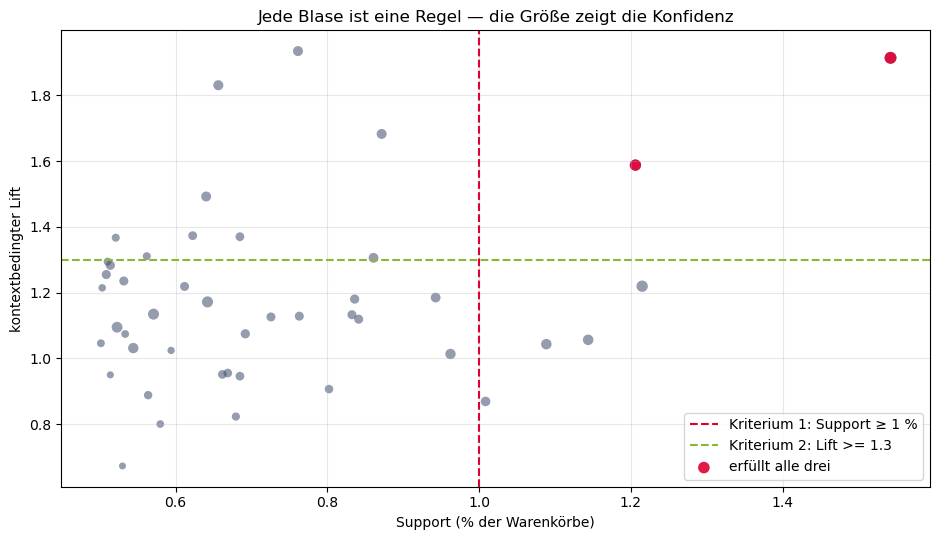

Regeln insgesamt:                 45
K1  Support ≥ 1%:                6
K2  Lift (Kontext) ≥ 1.3:       11
K3  Ziel ist eine Station:        35
alle drei zusammen:               2



A4 - SZENARIORECHNUNG JE REGEL (keine Obergrenze, kein Beweis)
   Angenommen: eine Umsetzrunde kostet 35 EUR,
   eine verhinderte Fahrt bringt 2.20 EUR. Beides gesetzt.
   Angenommen ausserdem: 1 Umsetzrunde je Tag - sonst
   liessen sich 'Wert je Tag' und 'Kosten je Runde' nicht vergleichen.
   Gerechnet wird, als waere jede beobachtete Regelfahrt ohne
   Umverteilung verloren gegangen. Das ist KEINE Obergrenze: Die
   Fahrten, die mangels Rad nie stattfanden, stehen nirgends in
   diesen Daten.
   Rentabel ab 16 zusaetzlichen Fahrten je Runde.

   Regel                                            Kontext  Fahrten/Tag  Wert/Tag
   Grombühl Klinikum -> Hauptbahnhof                Werktag         0.80     1.76 EUR
   Juliuspromenade -> Grombühl Klinikum             Werktag         1.02     2.25 EUR

   Im Szenario traegt keine Regel eine eigene Transportfahrt - es
   geht um rund eine Fahrt je Tag.

   ABER: Das WIDERLEGT A4 nicht. Die entgangene Nachfrage steht
   nicht in diesen Daten


BLOCKBOOTSTRAP ueber 1.218 Tage, 300 Ziehungen:
   Staerkste Regel: Juliuspromenade -> Grombühl Klinikum (Werktag · mittag (10-15))
   Lift im Datensatz: 1.93
   95-%-Bereich ueber Tagesziehungen: 1.78 bis 2.07
   Auch unter Tagesabhaengigkeit bleibt der Lift ueber 1 - der
   Befund traegt die Blockstruktur.
   Der Fisher-Test ignoriert diese Struktur; er faellt deshalb
   zuversichtlicher aus als der Bootstrap.

   Rueckrichtung Grombühl Klinikum -> Juliuspromenade (Werktag · abend (15-20)):
   111 Fahrten, Support 0.0020, Lift (Kontext) 1.16
   -> unter der Suchgrenze von 0.5%: taucht in KEINER
      Auswertung auf, auch nicht als 'durchgefallen'.

Die Regel mit dem groessten Support:
   Juliuspromenade -> Grombühl Klinikum  (Werktag · früh (0-10))
   Support 0.0154 = 1.54 %   Lift (Kontext) 1.91   867 Fahrten
   Zur Huerde von 1.00%: ueberschreitet sie um 0.54 Prozentpunkte.

   DIESELBE HUERDE, IN BETRIEBSGROESSEN:
   Diese Regel umfasst 867 Fahrten in 848 Werktagen
   = 1.02 Fahr

In [7]:
plt.figure(figsize=(9.5, 5.5))
LIFT = "Lift (Kontext)"
# Die Schwellen werden auf die UNGERUNDETEN Werte angewandt. Eine Regel mit
# Lift 1,296 darf nicht dadurch bestehen, dass sie in der Anzeige als 1,30
# erscheint - sonst entscheidet die Formatierung ueber die Freigabe.
plt.scatter(regeln.Support * 100, regeln[LIFT], s=regeln.Konfidenz * 220,
            alpha=.55, color="#3d4b6b", edgecolor="none")
plt.axvline(1.0, color="#e00034", ls="--", label="Kriterium 1: Support ≥ 1 %")
plt.axhline(K2_LIFT, color="#8AB833", ls="--", label=f"Kriterium 2: Lift >= {K2_LIFT}")
brauchbar = regeln[(regeln.Support >= K1_SUPPORT) & (regeln[LIFT] >= K2_LIFT)
                   & regeln["ziel_ist_station"]]
plt.scatter(brauchbar.Support * 100, brauchbar[LIFT], s=brauchbar.Konfidenz * 220,
            alpha=.9, color="#e00034", edgecolor="none", label="erfüllt alle drei")
plt.xlabel("Support (% der Warenkörbe)"); plt.ylabel("kontextbedingter Lift")
plt.title("Jede Blase ist eine Regel — die Größe zeigt die Konfidenz")
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

# DIESELBE PUNKTWOLKE, BEDIENBAR. Die statische Grafik daruber bleibt
# stehen: Sie traegt die Aussage auch dort, wo Skripte entfernt werden.
# Der Zusatz hier ist das Weiterlesen - welche Regel hinter einem Punkt
# steckt, steht sonst in keiner Achse.
_pw = regeln.assign(
    Gruppe=np.where(regeln.index.isin(brauchbar.index),
                    "erfuellt alle drei", "faellt durch"))
_fig = go.Figure()
for _name, _teil in _pw.groupby("Gruppe"):
    _fig.add_trace(go.Scatter(
        x=_teil.Support * 100, y=_teil[LIFT], mode="markers", name=_name,
        marker=dict(size=6 + _teil.Konfidenz * 26, opacity=.72,
                    line=dict(width=0)),
        customdata=np.stack([_teil["wenn Start"], _teil["dann Ziel"],
                             _teil.Kontext, _teil.Fahrten,
                             _teil.Konfidenz], axis=-1),
        hovertemplate=("<b>%{customdata[0]} → %{customdata[1]}</b><br>"
                       "%{customdata[2]}<br>"
                       "Support %{x:.2f} %   Lift %{y:.2f}<br>"
                       "%{customdata[3]} Fahrten, Konfidenz "
                       "%{customdata[4]:.0%}<extra></extra>")))
_fig.add_vline(x=K1_SUPPORT * 100, line=dict(dash="dash", color=FARBE["warnung"]))
_fig.add_hline(y=K2_LIFT, line=dict(dash="dash", color=FARBE["gut"]))
_fig.update_xaxes(title="Support (% der Warenkoerbe)")
_fig.update_yaxes(title="kontextbedingter Lift")
interaktiv(_fig, "Jede Blase ist eine Regel - zum Weiterlesen darauf zeigen")

print(f"Regeln insgesamt:                 {len(regeln)}")
print(f"K1  Support ≥ {K1_SUPPORT:.0%}:                {(regeln.Support >= K1_SUPPORT).sum()}")
print(f"K2  Lift (Kontext) ≥ {K2_LIFT}:       {(regeln[LIFT] >= K2_LIFT).sum()}")
print(f"K3  Ziel ist eine Station:        {int(regeln['ziel_ist_station'].sum())}")
merke("brauchbare_regeln", len(brauchbar))
print(f"alle drei zusammen:               {len(brauchbar)}")

# ─── WAS EINE REGEL BETRIEBLICH WERT IST ────────────────────────────
# Die beiden Kostengroessen standen bisher als "fehlt" im Text. Die
# Disposition hat sie geliefert - damit laesst sich rechnen statt vermuten.
_werktage_regel = koerbe[koerbe.tagesart == "Werktag"].startzeit.dt.date.nunique()
# ─── A4: NICHT PRUEFBAR - UND DAS IST ETWAS ANDERES ALS "GERISSEN" ──
#
# ACHTUNG, HIER STAND EIN DENKFEHLER, und er ist lehrreich genug, um
# ihn stehen zu lassen. Frueher hiess dieser Block "Obergrenzenrechnung"
# und schloss: Selbst im guenstigsten Fall traegt keine Regel eine
# Umsetzrunde, also faellt A4 durch.
#
# Das ist keine Obergrenze. Gezaehlt werden Fahrten, die ZUSTANDE
# GEKOMMEN sind. Gefragt ist aber, wie viele Fahrten OHNE Umverteilung
# ausgefallen waeren - und die koennen mehr, gleich viele oder weniger
# sein. Wenn eine Station morgens leer stand, erzeugt die verhinderte
# Fahrt keine Zeile: Sie ist in diesen Daten unsichtbar. Beobachtete
# Erfolge sind keine Schranke fuer entgangene Nachfrage.
#
# Dazu eine Einheit, die nicht passt: "Wert je Tag" gegen "Kosten je
# Runde" laesst sich nur vergleichen, wenn feststeht, wie viele Runden
# es je Tag gibt. Das stand nirgends.
#
# Das ehrliche Ergebnis lautet: A4 ist mit diesen Daten NICHT PRUEFBAR.
# Produkt A bleibt ohne Freigabe - aber wegen fehlender Evidenz, nicht
# wegen widerlegter Wirtschaftlichkeit. Der Unterschied entscheidet,
# was als naechstes zu tun ist: Daten beschaffen, nicht Verfahren
# verbessern.
#
# WAS FUER EINE ECHTE A4-PRUEFUNG FEHLT:
#   - zeitaufgeloeste Stationsbestaende und Kapazitaeten
#   - Leer- und Vollstandszeiten
#   - eine Schaetzung der nicht erfuellten Nachfrage
#   - Umverteilungsrichtung und -menge
#   - Rundenfrequenz sowie Personal- und Fahrzeugkosten
#   - moeglichst ein kausaler Vergleich mit und ohne Massnahme
#
# Die Rechnung bleibt als SZENARIO stehen - sie zeigt die
# Groessenordnung. Entscheiden darf sie nichts.
RUNDEN_JE_TAG = 1        # ANNAHME, damit die Einheiten ueberhaupt passen
merke("runden_je_tag", RUNDEN_JE_TAG)
KOSTEN_TRANSPORTFAHRT = 35.0   # ANNAHME: Fahrer und Fahrzeug je Umsetzrunde
WERT_FAHRT = 2.20              # ANNAHME: entgangener Umsatz je Fahrt
merke("kosten_transport", KOSTEN_TRANSPORTFAHRT); merke("wert_fahrt", WERT_FAHRT)

print("\nA4 - SZENARIORECHNUNG JE REGEL (keine Obergrenze, kein Beweis)")
print(f"   Angenommen: eine Umsetzrunde kostet {KOSTEN_TRANSPORTFAHRT:.0f} EUR,")
print(f"   eine verhinderte Fahrt bringt {WERT_FAHRT:.2f} EUR. Beides gesetzt.")
print(f"   Angenommen ausserdem: {RUNDEN_JE_TAG} Umsetzrunde je Tag - sonst")
print("   liessen sich 'Wert je Tag' und 'Kosten je Runde' nicht vergleichen.")
print("   Gerechnet wird, als waere jede beobachtete Regelfahrt ohne")
print("   Umverteilung verloren gegangen. Das ist KEINE Obergrenze: Die")
print("   Fahrten, die mangels Rad nie stattfanden, stehen nirgends in")
print("   diesen Daten.")
print(f"   Rentabel ab {KOSTEN_TRANSPORTFAHRT / WERT_FAHRT:.0f} zusaetzlichen "
      f"Fahrten je Runde.\n")
# JEDE REGEL MIT IHREM EIGENEN TAGESNENNER.
#
# Eine Regel im Kontext "frei · abend" betrifft keine Werktage. Sie
# durch Werktage zu teilen macht sie kleiner, als sie ist - und zwar
# genau dort, wo die Rechnung ueber eine Freigabe entscheidet.
_tage_je_art_alle = (koerbe.groupby("tagesart").startzeit.apply(
    lambda s: s.dt.date.nunique()).to_dict())
print(f"   {'Regel':46s}{'Kontext':>10s}{'Fahrten/Tag':>13s}{'Wert/Tag':>10s}")
_lohnt, _je_tag_max = 0, 0.0
for _, _r in brauchbar.iterrows():
    _art = str(_r.Kontext).split(" · ")[0]
    _nenner = _tage_je_art_alle.get(_art, 0)
    _je_tag = _r.Fahrten / _nenner if _nenner else float("nan")
    _je_tag_max = max(_je_tag_max, _je_tag)
    _wert = _je_tag * WERT_FAHRT
    _lohnt += _wert >= KOSTEN_TRANSPORTFAHRT
    print(f"   {_r['wenn Start'] + ' -> ' + _r['dann Ziel']:46s}{_art:>10s}"
          f"{_je_tag:>13.2f}{_wert:>9.2f} EUR")
merke("regeln_lohnen", _lohnt)
merke("regel_je_werktag", _je_tag_max)
print()
if _lohnt:
    print(f"   {_lohnt} Regel(n) tragen eine eigene Transportfahrt.")
else:
    print("   Im Szenario traegt keine Regel eine eigene Transportfahrt - es")
    print("   geht um rund eine Fahrt je Tag.")
    print()
    print("   ABER: Das WIDERLEGT A4 nicht. Die entgangene Nachfrage steht")
    print("   nicht in diesen Daten - eine Station, die morgens leer war,")
    print("   erzeugt keine Zeile. A4 ist damit NICHT PRUEFBAR.")

# SIND DIE STARKEN REGELN ZUFALL? Pruefen statt behaupten.
#
# ACHTUNG BEI DER TESTFAMILIE. Eine fruehere Fassung korrigierte mit 32 -
# der Zahl der Regeln, die den Supportfilter ueberlebt haben. Das ist zu
# klein: Der Filter ist DATENABHAENGIG, er hat also selbst schon
# ausgewaehlt. Wer nach einer Vorauswahl korrigiert, korrigiert nur den
# Rest und rechnet sich die Familie klein.
#
# Durchsucht wurden alle Kombinationen aus Tagesart, Fenster, Start und
# Ziel - ohne die Rundtouren, die in Phase 3 ausgeschlossen wurden.
FAMILIE = (koerbe.tagesart.nunique() * koerbe.fenster.nunique()
           * koerbe.start.nunique() * (koerbe.ziel.nunique() - 1))
regeln["p_korrigiert"] = (regeln.p * FAMILIE).clip(upper=1.0)
top10 = regeln.nlargest(10, LIFT)
print(f"\nTestfamilie: {koerbe.tagesart.nunique()} Tagesarten x "
      f"{koerbe.fenster.nunique()} Fenster x {koerbe.start.nunique()} Startstationen")
print(f"x {koerbe.ziel.nunique() - 1} moegliche Ziele = {FAMILIE} Kombinationen,")
print(f"nicht die {len(regeln)} Regeln, die den Supportfilter ueberlebt haben.")
print(f"\nVon den zehn Regeln mit dem hoechsten Lift halten "
      f"{int((top10.p_korrigiert < 0.05).sum())} von 10 einem Test auf")
print(f"Unabhaengigkeit stand (Fisher, Bonferroni-korrigiert auf {FAMILIE} Tests).")
print(f"Groesster korrigierter p-Wert unter diesen zehn: {top10.p_korrigiert.max():.5f}")
print()
print("Was dieser Test NICHT zeigt: Er behandelt jede Fahrt als unabhaengige")
print("Beobachtung. Dieselben Personen fahren aber wiederholt, und Fahrten")
print("desselben Tages haengen zusammen.")

# ─── BLOCKBOOTSTRAP UEBER TAGE ──────────────────────────────────────
# "Waere ehrlicher und faellt vermutlich schwaecher aus" - das ist eine
# Vermutung, und Vermutungen gehoeren gerechnet. Gezogen werden ganze TAGE
# mit Zuruecklegen: Ein Tag geht komplett hinein oder gar nicht. Damit
# bleibt erhalten, was der Fisher-Test wegdefiniert - dass Fahrten desselben
# Tages zusammenhaengen.
BOOTSTRAP_ZIEHUNGEN = 300
_rng = np.random.default_rng(42)
_tage = koerbe.startzeit.dt.normalize()
_nach_tag = {t: g for t, g in koerbe.groupby(_tage)}
_alle_tage = list(_nach_tag)

_top = regeln.nlargest(1, LIFT).iloc[0]
_lifts = []
for _ in range(BOOTSTRAP_ZIEHUNGEN):
    _wahl = _rng.choice(len(_alle_tage), size=len(_alle_tage), replace=True)
    _stich = pd.concat([_nach_tag[_alle_tage[i]] for i in _wahl])
    _raum = _stich[(_stich.tagesart == _top.Kontext.split(" · ")[0])
                   & (_stich.fenster == _top.Kontext.split(" · ")[1])]
    if not len(_raum):
        continue
    _ab = _raum[_raum.start == _top["wenn Start"]]
    _basis = (_raum.ziel == _top["dann Ziel"]).mean()
    if not len(_ab) or _basis <= 0:
        continue
    _lifts.append((_ab.ziel == _top["dann Ziel"]).mean() / _basis)

_u, _o = np.percentile(_lifts, [2.5, 97.5])
merke("block_lift_unten", _u); merke("block_lift_oben", _o)
merke("block_ziehungen", BOOTSTRAP_ZIEHUNGEN)
_tage_text = f"{len(_alle_tage):,d}".replace(",", ".")
print(f"\nBLOCKBOOTSTRAP ueber {_tage_text} Tage, {BOOTSTRAP_ZIEHUNGEN} Ziehungen:")
print(f"   Staerkste Regel: {_top['wenn Start']} -> {_top['dann Ziel']} "
      f"({_top.Kontext})")
print(f"   Lift im Datensatz: {_top[LIFT]:.2f}")
print(f"   95-%-Bereich ueber Tagesziehungen: {_u:.2f} bis {_o:.2f}")
if _u > 1.0:
    print("   Auch unter Tagesabhaengigkeit bleibt der Lift ueber 1 - der")
    print("   Befund traegt die Blockstruktur.")
else:
    print("   Unter Tagesabhaengigkeit reicht der Bereich unter 1 - was der")
    print("   Fisher-Test als sicher auswies, ist es dann nicht.")
print("   Der Fisher-Test ignoriert diese Struktur; er faellt deshalb")
print("   zuversichtlicher aus als der Bootstrap.")

# Wie knapp scheitert die STAERKSTE Regel? Und vor allem: was verlangt die
# Huerde eigentlich, wenn man sie in Fahrten je Werktag uebersetzt?
beste = regeln.loc[regeln.Support.idxmax()]
werktage = koerbe[koerbe.tagesart == "Werktag"].startzeit.dt.date.nunique()
# Diese Regel wird im Fliesstext mehrfach als Beispiel genannt. Ihr Name
# steht deshalb nicht dort, sondern hier.
merke("top_start", beste["wenn Start"]); merke("top_ziel", beste["dann Ziel"])
merke("top_kontext", beste.Kontext)
merke("top_lift_kontext", beste[LIFT]); merke("top_lift_klassisch", beste["Lift (klassisch)"])
merke("top_fahrten", int(beste.Fahrten))
merke("mindest_support", MINDEST_SUPPORT)

# Die RUECKRICHTUNG derselben Verbindung - im spiegelbildlichen Zeitfenster.
# Sie steht meist NICHT in der Regelliste, und der Fliesstext unten macht
# daraus eine Lehre. Damit die Lehre stimmt, wird hier nachgesehen statt
# behauptet.
_ruecktag = beste.Kontext.split(" · ")[0]
_rueckfenster = "abend (15-20)" if "früh" in beste.Kontext else "früh (0-10)"
_rueckraum = koerbe[(koerbe.tagesart == _ruecktag) & (koerbe.fenster == _rueckfenster)]
_ab = _rueckraum[_rueckraum.start == beste["dann Ziel"]]
_hin = _ab[_ab.ziel == beste["wenn Start"]]
_r_support = len(_hin) / max(len(koerbe), 1)
_r_basis = (_rueckraum.ziel == beste["wenn Start"]).mean()
merke("rueck_fenster", _rueckfenster)
merke("rueck_fahrten", len(_hin))
merke("rueck_support", _r_support)
merke("rueck_lift", (len(_hin) / max(len(_ab), 1)) / max(_r_basis, 1e-9))
merke("rueck_in_liste", int(_r_support >= MINDEST_SUPPORT))
print(f"\n   Rueckrichtung {beste['dann Ziel']} -> {beste['wenn Start']} "
      f"({_ruecktag} · {_rueckfenster}):")
print(f"   {len(_hin)} Fahrten, Support {_r_support:.4f}, "
      f"Lift (Kontext) {(len(_hin) / max(len(_ab), 1)) / max(_r_basis, 1e-9):.2f}")
if _r_support < MINDEST_SUPPORT:
    print(f"   -> unter der Suchgrenze von {MINDEST_SUPPORT:.1%}: taucht in KEINER")
    print("      Auswertung auf, auch nicht als 'durchgefallen'.")
else:
    print(f"   -> ueber der Suchgrenze von {MINDEST_SUPPORT:.1%}: sie steht in der Liste.")
print(f"\nDie Regel mit dem groessten Support:")
print(f"   {beste['wenn Start']} -> {beste['dann Ziel']}  ({beste.Kontext})")
print(f"   Support {beste.Support:.4f} = {beste.Support * 100:.2f} %"
      f"   Lift (Kontext) {beste[LIFT]:.2f}   {int(beste.Fahrten)} Fahrten")
# "Fehlen" gilt nur unterhalb der Huerde. Oberhalb ergaeben sich negative
# fehlende Prozentpunkte - eine Formulierung, die es nicht gibt.
_abstand_pp = (beste.Support - K1_SUPPORT) * 100
_abstand_f = beste.Fahrten - K1_SUPPORT * len(koerbe)
_wort = "ueberschreitet sie um" if _abstand_pp >= 0 else "verfehlt sie um"
print(f"   Zur Huerde von {K1_SUPPORT:.2%}: {_wort} {abs(_abstand_pp):.2f} Prozentpunkte.")
print()
print("   DIESELBE HUERDE, IN BETRIEBSGROESSEN:")
print(f"   Diese Regel umfasst {int(beste.Fahrten)} Fahrten in {werktage} Werktagen")
print(f"   = {beste.Fahrten / werktage:.2f} Fahrten je Werktag.")
print(f"   Die Huerde verlangt {K1_SUPPORT * len(koerbe) / werktage:.2f} Fahrten je Werktag.")
print(f"   Der Abstand betraegt {abs(_abstand_f):.0f} Fahrten ueber den ganzen Zeitraum")
print(f"   - rund {abs(_abstand_f) / werktage * 100:.1f} Hundertstel einer Fahrt je Werktag.")
# Die beiden Zahlen, die im Schlussteil die Huerde greifbar machen.
# Frueher standen dort 0,68 und 0,69 fest im Text - Werte eines alten
# Datenstands, die kein Lauf mehr erzeugt.
merke("huerde_je_werktag", float(K1_SUPPORT * len(koerbe) / werktage))
merke("top_je_werktag", float(beste.Fahrten / werktage))
merke("top_support", beste.Support)
merke("top_abstand_pp", _abstand_pp)
_ = merke("k1_support", K1_SUPPORT)

### 5.1 Support und Lift im Streudiagramm

Die Punktwolke fällt nach rechts ab. Der übliche Grund dafür — je spezieller eine Regel,
desto kleiner ihr Support — greift hier **nicht**: Alle Regeln sind gleich spezifisch,
denn Tagesart, Zeitfenster und Startstation sagen jeweils genau ein Ziel voraus. Keine
ist die Erweiterung einer anderen. Die unterschiedlichen Supportwerte kommen allein
daher, dass manche Start-Ziel-Paare häufiger sind als andere.

Was das Bild zeigt, ist einfacher: Bei kleinem Support streut der Lift stärker, weil er
aus kleinen Zählwerten gebildet wird. **Was wie ein Zusammenhang aussieht, ist der Rand
einer Verteilung.** Die Regeln mit den höchsten Lift-Werten stehen links oben — bei einem
Support von Bruchteilen eines Prozents und damit ohne Nutzen für die Disposition.

### Signifikanzprüfung der stärksten Regeln

Für jede Regel liegt eine Vierfeldertafel vor: Fahrten ab dieser Station in diesem
Fenster zu diesem Ziel gegen alle übrigen. Fishers exakter Test prüft, ob eine solche
Häufung bei Unabhängigkeit plausibel wäre.

**Korrigiert wird über die Zahl der durchsuchten Kombinationen, nicht über die der
gefundenen Regeln.** Der Supportfilter ist datenabhängig und hat bereits ausgewählt; wer
erst danach korrigiert, rechnet die Testfamilie klein. Durchsucht wurden **800**
Kombinationen aus Tagesart, Fenster, Start und Ziel; mit 800 wird multipliziert
(**Bonferroni-Korrektur**). Das Ergebnis steht in der Ausgabe oben.

**Was daraus folgt und was nicht.** Die Häufungen sind unter dem gewählten
Unabhängigkeitsmodell auch nach konservativer Korrektur auffällig. Real sind sie damit
nicht belegt: Fishers Test behandelt jede Fahrt als unabhängige Beobachtung, während
dieselben Personen wiederholt fahren und Fahrten desselben Tages zusammenhängen. Fällt
die Unabhängigkeitsannahme, fällt die Aussage mit. Belastbar ist deshalb nur die
Kombination aus statistischer Auffälligkeit und Bestätigung in einem späteren Zeitraum
(Phase 5.3) — ein Stabilitätsindiz, kein Signifikanznachweis und kein Beleg
betrieblicher Relevanz.

**Statistisch auffällig und betrieblich relevant sind zwei verschiedene Dinge.** Die
Assoziationsanalyse liefert nur das erste. Hier scheitern die Regeln nicht an der
Signifikanz, sondern an der Größe. Ohne die Support-Untergrenze von 0,5 % bei der Suche
stünden hier Regeln mit drei oder vier Fahrten und Lift-Werten jenseits von 10 — die
wären tatsächlich meist Zufall.

### 5.2 Regeln, die A1 bis A3 erfüllen

In [8]:
ergebnis = brauchbar.sort_values(["Kontext", LIFT], ascending=[True, False])
print(ergebnis[anzeige].to_string(index=False) if len(ergebnis)
      else "(leer — keine Regel erfüllt alle drei Kriterien)")
print()
if len(ergebnis) == 0:
    print("KEINE REGEL nimmt alle drei Huerden. Das ist ein Ergebnis, kein Fehler -")
    print("aber es heisst auch: es gibt nichts auszuliefern.")
else:
    print(f"{len(ergebnis)} Regel(n) nehmen die Huerden A1 bis A3.")
    print("Das ist NICHT dasselbe wie eine Betriebsfreigabe: A1-A3 sind")
    print("statistische Mindestanforderungen. Ob sich eine Transporterfahrt")
    print("lohnt, entscheidet A4 - und dafuer stehen zwei GESETZTE")
    print("Szenarioannahmen bereit (Kosten je Runde, Wert je Fahrt). Was")
    print("fehlt, sind nicht die Zahlen, sondern ihre Messung.")

              Kontext        wenn Start         dann Ziel  Fahrten  Support  Konfidenz  Lift (Kontext)  Lift (klassisch)
Werktag · früh (0-10)   Juliuspromenade Grombühl Klinikum      867 0.015420   0.332566        1.913645          2.999978
Werktag · früh (0-10) Grombühl Klinikum      Hauptbahnhof      678 0.012058   0.302949        1.587540          2.445601

2 Regel(n) nehmen die Huerden A1 bis A3.
Das ist NICHT dasselbe wie eine Betriebsfreigabe: A1-A3 sind
statistische Mindestanforderungen. Ob sich eine Transporterfahrt
lohnt, entscheidet A4 - und dafuer stehen zwei GESETZTE
Szenarioannahmen bereit (Kosten je Runde, Wert je Fahrt). Was
fehlt, sind nicht die Zahlen, sondern ihre Messung.


**2 Regel(n) nehmen alle drei Hürden aus Phase 1.** Die
supportstärkste — Werktag · früh (0-10) von „Juliuspromenade" nach „Grombühl Klinikum" — erreicht
1,54 % Support gegenüber der Hürde von 1 %.

Zwei Einordnungen gehören dazu. **Erstens ist „stärkste Regel" zweideutig:** Die Regel
mit dem größten Lift ist in aller Regel eine andere als die mit dem größten Support. Die
Tabelle in Phase 4 zeigt beide Spalten, damit die Wahl nicht nachträglich getroffen
werden kann. **Zweitens heißt A1 bis A3 erfüllt nicht freigegeben:** Diese Hürden sagen,
wann ein Muster groß und deutlich genug ist, um betrachtet zu werden. Ob ein Transporter
fährt, entscheidet A4 — und dessen Beträge sind gesetzte Szenarioannahmen.

### Die Support-Hürde auf der Betriebsskala

Die Begründung für die Ein-Prozent-Hürde lautete in Phase 1: *„Für eine Regel, die
zwanzig Fahrten im Jahr betrifft, fährt kein Transporter."* Das ist eine Aussage über
**Fahrten je Tag**. Gemessen wurde aber ein **Anteil an allen Warenkörben über drei
Jahre** — eine andere Skala. Die Ausgabe oben rechnet beide ineinander um: Die Hürde
verlangt 0,66 Fahrten je Werktag, die supportstärkste Regel mit
867 Fahrten bringt 1,02.

Beide Werte liegen weit unterhalb dessen, was eine Transporterfahrt rechtfertigt. Die
Hürde trennt damit nicht „lohnt sich" von „lohnt sich nicht", sondern zwei
Größenordnungen, in denen ohnehin kein Transporter fährt. **Das Kriterium war auf der
falschen Skala formuliert** — nicht zu streng und nicht zu lax.

### Warum die Hürde nicht angepasst wird

Die Hürde wird **nicht** ersetzt und die Rechnung nicht wiederholt. Ein Kriterium, das
nach dem Ergebnis geändert wird, misst nichts mehr — auch dann nicht, wenn die Änderung
sachlich richtig ist; der Verdacht der Anpassung an das gewünschte Ergebnis lässt sich
nachträglich nicht ausräumen.

Für **Produkt A** lautet das Ergebnis damit nicht freigegeben (Wirtschaftlichkeit nicht prüfbar); der Mangel wird protokolliert
statt repariert. Für eine zweite Runde gehört das Kriterium neu formuliert, **vor** der
nächsten Messung und in der Einheit der Disposition: *mindestens N Fahrten je Werktag,
wobei N aus den Kosten einer Transporterfahrt hergeleitet wird.*

Dass diese Zahl heute fehlt, ist selbst ein Befund: **Gemessene Kosten einer
Transporterfahrt lagen nie vor.** Die 35 € je Runde und
2,20 € je Fahrt sind gesetzte Szenarioannahmen.

### 5.3 Entdeckung und Bestätigung trennen

Alles bisher Gerechnete hat **denselben Datensatz zum Suchen und zum Bewerten** benutzt.
Bei einer Regelsuche wiegt das schwer: 800 Kombinationen wurden durchgesehen und die
auffälligsten behalten. Ob sie auch in einem Zeitraum auffällig sind, den die Suche nie
gesehen hat, ist damit offen.

Die Gegenprobe: Regeln in den ersten zwei Dritteln **suchen**, im letzten Drittel
**nachsehen**.

In [9]:
# ─── JETZT WIRD DIE VERSIEGELUNG GEOEFFNET - EINMAL ─────────────────
#
# Der Schnitt liegt nicht hier, sondern in Phase 3, VOR der ersten
# Suche. Alles, was bis hierher gerechnet wurde - Regeln, Rangliste,
# Fisher, Bootstrap, Deutungen -, sah ausschliesslich den
# Entdeckungszeitraum.
#
# Ab jetzt wird der Bestaetigungszeitraum gelesen. Danach wird an
# keiner Schwelle mehr gedreht; die Regelmenge steht fest.
print(f"Entdeckung:   bis {GRENZE.date()}   {len(entdeckung):,d} Fahrten".replace(",", "."))
print(f"Bestaetigung: danach            {len(bestaetigung):,d} Fahrten\n".replace(",", "."))

r_ent = regeln_finden(entdeckung, ["tagesart", "fenster"])
gewaehlt_ent = r_ent[(r_ent.Support >= MINDEST_SUPPORT) & (r_ent[LIFT] >= K2_LIFT)]

# Im Bestaetigungszeitraum OHNE Supportfilter nachrechnen - wir wollen die
# ausgewaehlten Regeln wiederfinden, nicht neu suchen.
r_best = regeln_finden(bestaetigung, ["tagesart", "fenster"], mindest_support=0.0)
schluessel = ["Kontext", "wenn Start", "dann Ziel"]
zusammen = gewaehlt_ent[schluessel + [LIFT, "Support"]].merge(
    r_best[schluessel + [LIFT, "Support"]], on=schluessel,
    how="left", suffixes=(" entdeckt", " bestätigt"))

print(f"Im Entdeckungszeitraum ausgewaehlt (Support >= {MINDEST_SUPPORT:.1%}, "
      f"Lift >= {K2_LIFT}): {len(gewaehlt_ent)} Regeln")
haelt_13 = int((zusammen[f"{LIFT} bestätigt"] >= K2_LIFT).sum())
merke("split_haelt", haelt_13); merke("split_gesamt", len(zusammen))
haelt_1 = int((zusammen[f"{LIFT} bestätigt"] > 1.0).sum())
print(f"   davon spaeter weiterhin Lift >= {K2_LIFT}:  {haelt_13} von {len(zusammen)}")
print(f"   davon spaeter weiterhin Lift > 1:    {haelt_1} von {len(zusammen)}\n")
from IPython.display import display
display(stil(zusammen.round(3), balken=f"{LIFT} bestätigt"))

# ─── VIER TEILFENSTER DES BESTAETIGUNGSZEITRAUMS ────────────────────
# Ein einziger Schnitt legt das Bestaetigungsfenster auf eine bestimmte
# Jahreszeit. Faellt es guenstig, sieht jede Regel stabil aus; faellt es
# unguenstig, keine. Vier gleich lange Teilfenster, jedes gegen dieselben
# im ersten Drittel entdeckten Regeln - so laesst sich Saison von
# Stabilitaet trennen.
#
# DAS IST KEINE ROLLIERENDE VALIDIERUNG, und der Unterschied ist wichtig
# genug fuer diesen Kommentar: Bei einem Rolling Origin wuerde in JEDEM
# Fold neu gesucht, und zwar nur in dessen eigener Vergangenheit. Hier
# steht die Regelmenge fest und wird viermal nachgerechnet. Das prueft
# Saisonabhaengigkeit, nicht die Suchstrategie.
print("\nDIESELBEN REGELN IN VIER TEILFENSTERN DES BESTAETIGUNGSZEITRAUMS:")
# "koerbe" ist jetzt der Entdeckungszeitraum - die Teilfenster liegen
# im BESTAETIGUNGSzeitraum und muessen dort gebildet werden.
_rest = bestaetigung
_grenzen = pd.date_range(_rest.startzeit.min(), _rest.startzeit.max(), periods=5)
print(f"   {'Fenster':>26s}{'Fahrten':>9s}{'Lift >= ' + str(K2_LIFT):>12s}"
      f"{'Lift > 1':>10s}")
_haelt_je_fenster = []
for _i in range(4):
    _teil = _rest[(_rest.startzeit >= _grenzen[_i])
                  & (_rest.startzeit < _grenzen[_i + 1])]
    _rb = regeln_finden(_teil, ["tagesart", "fenster"], mindest_support=0.0)
    _z = gewaehlt_ent[schluessel].merge(_rb[schluessel + [LIFT]], on=schluessel,
                                        how="left")
    _h13 = int((_z[LIFT] >= K2_LIFT).sum()); _h1 = int((_z[LIFT] > 1.0).sum())
    _haelt_je_fenster.append(_h13)
    _bez = f"{_grenzen[_i].date()} bis {_grenzen[_i + 1].date()}"
    print(f"   {_bez:>26s}{len(_teil):>9,d}{_h13:>9d}/{len(_z)}"
          f"{_h1:>8d}/{len(_z)}".replace(",", "."))
merke("fenster_min", min(_haelt_je_fenster)); merke("fenster_max", max(_haelt_je_fenster))
merke("fenster_regeln", len(gewaehlt_ent))
print()
if min(_haelt_je_fenster) == max(_haelt_je_fenster):
    print(f"   In jedem Fenster halten {min(_haelt_je_fenster)} von "
          f"{len(gewaehlt_ent)} Regeln die Lift-Huerde.")
else:
    print(f"   Zwischen {min(_haelt_je_fenster)} und {max(_haelt_je_fenster)} von "
          f"{len(gewaehlt_ent)} Regeln halten die Huerde - je nach Fenster.")
    print("   Ein einzelner Schnitt haette einen dieser Werte geliefert und")
    print("   ihn wie ein Ergebnis aussehen lassen.")

Entdeckung:   bis 2024-12-24   56.226 Fahrten
Bestaetigung: danach            37.144 Fahrten

Im Entdeckungszeitraum ausgewaehlt (Support >= 0.5%, Lift >= 1.3): 11 Regeln
   davon spaeter weiterhin Lift >= 1.3:  9 von 11
   davon spaeter weiterhin Lift > 1:    11 von 11



Kontext,wenn Start,dann Ziel,Lift (Kontext) entdeckt,Support entdeckt,Lift (Kontext) bestätigt,Support bestätigt
Werktag · früh (0-10),Grombühl Klinikum,Hauptbahnhof,1.588000,0.012000,1.483000,0.011000
Werktag · früh (0-10),Juliuspromenade,Grombühl Klinikum,1.914000,0.015000,1.508000,0.010000
Werktag · früh (0-10),Marktplatz,Grombühl Klinikum,1.306000,0.009000,1.444000,0.009000
Werktag · mittag (10-15),Grombühl Klinikum,Hauptbahnhof,1.830000,0.007000,1.679000,0.006000
Werktag · mittag (10-15),Grombühl Klinikum,Hubland Campus,1.492000,0.006000,1.351000,0.006000
Werktag · mittag (10-15),Juliuspromenade,Grombühl Klinikum,1.934000,0.008000,1.553000,0.005000
Werktag · abend (15-20),Grombühl Klinikum,Hauptbahnhof,1.682000,0.009000,1.583000,0.008000
Werktag · abend (15-20),Hauptbahnhof,Sanderau,1.370000,0.007000,1.236000,0.006000
Werktag · abend (15-20),Hauptbahnhof,Grombühl Klinikum,1.311000,0.006000,1.270000,0.005000
Werktag · abend (15-20),Sanderau,Zellerau,1.367000,0.005000,1.441000,0.005000



DIESELBEN REGELN IN VIER TEILFENSTERN DES BESTAETIGUNGSZEITRAUMS:
                      Fenster  Fahrten Lift >= 1.3  Lift > 1
    2024-12-24 bis 2025-05-25    6.454        9/11      11/11


    2025-05-25 bis 2025-10-24   13.053        9/11      11/11
    2025-10-24 bis 2026-03-25    4.582        9/11      11/11


    2026-03-25 bis 2026-08-24   13.054        8/11      11/11

   Zwischen 8 und 9 von 11 Regeln halten die Huerde - je nach Fenster.
   Ein einzelner Schnitt haette einen dieser Werte geliefert und
   ihn wie ein Ergebnis aussehen lassen.


**Das ist ein gutes Stabilitätsindiz** — und es ist mehr wert als jeder p-Wert oben, weil
es einen Zeitraum benutzt, den die Suche nicht gesehen hat.

Drei Einschränkungen gehören dazu:

1. **Der Bestätigungszeitraum ist damit verbraucht.** Wer ihn jetzt benutzt, um Schwellen
   nachzujustieren, hat wieder auf denselben Daten gesucht und bewertet.
2. **Ein einziger Schnitt ist keine Zeitreihenvalidierung.** 2023 und 2026 sind
   Teiljahre; rollierende Fenster wären sauberer.
3. **Stabilität ist nicht Relevanz.** Eine Regel kann drei Jahre stabil und trotzdem zu
   klein für eine Maßnahme sein — genau das ist hier der Fall.

### 5.4 Durchgefallene Regeln als Hypothesen

Die 11 Regeln, die wenigstens die Lift-Hürde nehmen, dürfen den Umlaufplan nicht
begründen. Ansehen darf man sie trotzdem — sie sind eine **Hypothese**, kein Befund, und
sie werden gleich unabhängig überprüft.

Ein Muster sticht heraus: **morgens** fließt es aus den Wohnlagen in Richtung Arbeit und
Studium. Die supportstärkste Regel der Liste ist Werktag · früh (0-10) von „Juliuspromenade" nach
„Grombühl Klinikum" mit 867 Fahrten.

**Die naheliegende Fortsetzung lautet: abends fließt dasselbe zurück.** Diese Aussage
lässt sich aus der Regelliste nicht ableiten: **Die Rückrichtung steht dort gar nicht.**

Sehen Sie in der Ausgabe oben nach: Die Rückrichtung „Grombühl Klinikum" → „Juliuspromenade"
im Fenster abend (15-20) kommt auf 111 Fahrten, einen Support von
0,20 % und einen kontextbedingten Lift von 1,16. Die
Verbindung existiert also — die Frage ist, ob sie die Suchgrenze von
0,5 % überhaupt erreicht, mit der die Regelsuche begonnen hat. Was
darunter liegt, wurde aussortiert, bevor irgendein Erfolgskriterium es zu sehen bekam.

> **Das ist ein Fallstrick, der leicht zu übersehen ist.** Der `mindest_support` in der
> Suchfunktion ist kein Erfolgskriterium, sondern ein Filter *davor*. Was er entfernt,
> taucht in keiner Auswertung mehr auf — auch nicht als „durchgefallen". Wer über eine
> Regelliste redet, muss diese Untergrenze mitnennen, sonst redet er über eine Auswahl,
> deren Rand er nicht kennt.

Für den Transporter bleibt die Deutung dennoch plausibel: Die Uni-Stationen haben
vormittags einen **positiven Nettozufluss**, die Pendlerstationen einen negativen. (Ob sie
dabei tatsächlich „voll laufen", sagen die Fahrtdaten nicht — dafür bräuchte es
Bestände.) **Aber sie ist eine Deutung.** Ob
tatsächlich dieselben Menschen morgens hin- und abends zurückfahren, hat die
Assoziationsanalyse nicht gemessen und kann sie nicht messen — sie zählt Fahrten, nicht
Personen. Die nächste Zelle sieht deshalb in den `kunde_id` nach.

In [10]:
# DIE GEGENPROBE ZUR DEUTUNG: fahren morgens und abends dieselben Leute -
# und zwar AM SELBEN TAG? Nur dann ist es eine Hin- und Rueckfahrt.
KOERBE_ALLE["datum"] = KOERBE_ALLE.startzeit.dt.normalize()

# HIER STAND EIN FILTERFEHLER, und er ist typisch fuer jede Umstellung:
# Gefiltert wurde KOERBE_ALLE, aber zwei der vier Bedingungen kamen aus
# koerbe - dem kuerzeren Entdeckungszeitraum. Pandas richtet solche
# Masken still am Index aus; das Ergebnis war stillschweigend nur das
# erste Drittel, waehrend der Text "in fuenf Jahren" behauptete.
#
# Kein Absturz, keine Warnung, nur zu kleine Zahlen. Deshalb steht die
# Menge jetzt EINMAL in einer Variablen und wird nur noch aus ihr
# gefiltert.
_alle = KOERBE_ALLE
morgens = _alle[(_alle.tagesart == "Werktag") & (_alle.fenster == "früh (0-10)")
                & (_alle.start == "Hauptbahnhof") & (_alle.ziel == "Hubland Campus")]
abends = _alle[(_alle.tagesart == "Werktag") & (_alle.fenster == "abend (15-20)")
               & (_alle.start == "Hubland Campus") & (_alle.ziel == "Hauptbahnhof")]

# Zwei verschiedene Fragen, die leicht zu verwechseln sind:
irgendwann = set(morgens.kunde_id) & set(abends.kunde_id)
am_selben_tag = (set(zip(morgens.kunde_id, morgens.datum))
                 & set(zip(abends.kunde_id, abends.datum)))

print(f"Fahrten Hauptbahnhof -> Hubland  (werktags früh):  {len(morgens):>5d}")
print(f"Fahrten Hubland -> Hauptbahnhof  (werktags abends): {len(abends):>5d}")
print()
print(f"Personen mit Morgenfahrt:                           {morgens.kunde_id.nunique():>5d}")
print(f"Personen mit Abendfahrt:                            {abends.kunde_id.nunique():>5d}")
print(f"Personen, die IRGENDWANN beides taten:               {len(irgendwann):>5d}")
print(f"Hin- und Rückfahrt AM SELBEN TAG:                   {len(am_selben_tag):>5d}")
print()
merke("hin_fahrten", len(morgens)); merke("rueck_fahrten_paar", len(abends))
merke("personen_morgens", morgens.kunde_id.nunique())
merke("personen_abends", abends.kunde_id.nunique())
merke("personen_irgendwann", len(irgendwann))
merke("personen_selber_tag", len(am_selben_tag))
_n_tag = len(am_selben_tag)
merke("tagesprobe_satz",
      "an keinem einzigen gemeinsamen Tag" if _n_tag == 0
      else "und nur eine einzige davon am selben Tag" if _n_tag == 1
      else f"und nur {_n_tag} davon am selben Tag")
merke("anteil_irgendwann", len(irgendwann) / max(abends.kunde_id.nunique(), 1))

# Der else-Zweig fehlte. Er wurde nie gebraucht, solange die Zahl null war -
# und genau deshalb stand im Fliesstext daneben "keinen einzigen Tag", auch
# als es einen gab. Ein Zweig ohne Gegenstueck ist eine Behauptung mit
# Ablaufdatum.
if len(am_selben_tag) == 0:
    print("NULL. Nicht wenige - keine einzige.")
    print("Die Deutung 'dieselben Menschen fahren hin und zurueck' ist damit")
    print("widerlegt, nicht bestaetigt und nicht zurechtgerueckt.")
else:
    print(f"{len(am_selben_tag)} von {len(abends)} Abendfahrten - das ist")
    print(f"{len(am_selben_tag) / max(len(abends), 1):.2%} und traegt die Deutung nicht.")
    print("'Dieselben Menschen fahren hin und zurueck' waere eine Aussage")
    print("ueber viele; gemessen sind es Einzelfaelle.")

Fahrten Hauptbahnhof -> Hubland  (werktags früh):    245
Fahrten Hubland -> Hauptbahnhof  (werktags abends):   410

Personen mit Morgenfahrt:                             198
Personen mit Abendfahrt:                              323
Personen, die IRGENDWANN beides taten:                  68
Hin- und Rückfahrt AM SELBEN TAG:                       1

1 von 410 Abendfahrten - das ist
0.24% und traegt die Deutung nicht.
'Dieselben Menschen fahren hin und zurueck' waere eine Aussage
ueber viele; gemessen sind es Einzelfaelle.


**Die Deutung trägt nicht.** In fünf Jahren gibt es 1 Fälle, in
denen dieselbe Person morgens vom Bahnhof zum Campus und abends zurückgefahren ist — bei
410 Abendfahrten.

Eine Fehldeutung liegt dabei nahe: 68 Personen haben
*irgendwann* beide Richtungen benutzt, das sind 21,1 % von
323. Diese Zahl als abgeschwächte Bestätigung zu lesen, wäre falsch:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Was gezählt wurde</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Was daraus gelesen wurde</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">68 Personen benutzten <em>irgendwann</em> beide Richtungen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">„68 Personen fahren hin und zurück"</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Über alle Werktage hinweg, in beliebiger Kombination</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">ein täglicher Pendelweg</td></tr>
</tbody></table>
<div style="clear:both"></div>

Zwischen beiden Sätzen liegt die **Tagesbindung**. Ohne sie zählt man Personen, die im
März einmal hin- und im Oktober einmal zurückgefahren sind, als Pendler.

Support, Konfidenz und Lift der Hin-Richtung sind davon unberührt; die Kennzahlen
stimmen. Falsch war die Deutung daneben. Für die Maßnahme ändert sich nichts: Die Räder
laufen am Campus auf, unabhängig davon, wer sie dorthin gefahren hat.

### 5.5 Freigabeurteil

**A1 bis A3 sind erfüllt, Produkt A ist trotzdem nicht freigegeben (Wirtschaftlichkeit nicht prüfbar).** Was fehlt, ist A4 — und
zwar nicht, weil Kostenzahlen fehlten: 35 € je Umsetzrunde und
2,20 € je Fahrt stehen in Phase 1, sind aber **gesetzte
Szenarioannahmen**. Selbst mit ihnen trägt keine Regel eine eigene Runde. Die Zahlen je
Hürde stehen in der Kriterienausgabe in Phase 5.

**Produkt B ist davon unberührt: analytisches Lehr-Gate bestanden — keine reale Betriebsfreigabe.** Der Dispositionshinweis löst keine Fahrt
aus und braucht deshalb keinen Wirtschaftlichkeitsnachweis; seine vier Kriterien werden
im Code geprüft.

Daraus ergeben sich drei Wege:

1. **Die Hürde nachträglich verschieben** — unzulässig, in beide Richtungen. Sie stand
   vor der Messung fest.
2. **Regeln mit mehreren Bedingungen suchen.** Das hilft hier nicht: Jede zusätzliche
   Bedingung verkleinert die Menge der zutreffenden Körbe, **der Support kann dadurch nur
   sinken**. Genau darauf beruht der Apriori-Algorithmus. Beim Lift ist die Richtung
   offen — und knapp ist hier der Support.
3. **Zurück zu Phase 1**, das Kriterium in Fahrten je Werktag neu formulieren und die
   Kosten einer Transporterfahrt beschaffen. Das ist ein Gespräch mit der Disposition,
   keine Änderung im Notebook.

Der Ertrag dieses Notebooks steckt damit nicht in den Regeln, sondern in Phase 6, die
ohne jede Regel auskommt.

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Was ausgeliefert wird — ein Hinweis für Menschen, kein Transportauftrag.

<table align="left" style="border-collapse:separate;border-spacing:8px 0;margin:6px 0 20px -8px"><tbody><tr><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">6</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Regeln im Artefakt</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">1,02</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Fahrten je Tag, größte Regel</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">25,7</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">Räder je Werktag zu bewegen</div></td><td style="background:#FAFAFA;border:1px solid #D8D8D8;border-left:4px solid #2F2F2F;padding:10px 16px;vertical-align:top"><div style="font-size:1.5em;font-weight:600;color:#2F2F2F;line-height:1.2">91 %</div><div style="font-size:0.85em;color:#6A6A6A;margin-top:2px">frei abgestellt bei anderer Station</div></td></tr></tbody></table><div style="clear:both"></div>

> **Achtung, hier wechselt die Analyse.** Was jetzt kommt, folgt **nicht** aus den Regeln.
> Produkt A ist nicht freigegeben (Wirtschaftlichkeit nicht prüfbar), und was unten steht, ist mit keiner einzigen Regel
> gerechnet.
>
> Eine Überschrift wie *„Aus Regeln wird ein Umlaufplan für den Transporter"* wäre
> deshalb unzutreffend: Der Umlauf- und Einsammelteil ist eine
> **eigene, explorative Auswertung** der Nettoflüsse und der Endkoordinaten. Sie braucht
> eine eigene Geschäftsfrage, eigene Erfolgskriterien und eine eigene Validierung — alles
> drei hat sie nicht.
>
> **Was hier entsteht, ist Planungsinput.** Der Unterschied ist nicht sprachlich: Eine
> freigegebene Analyse hat vorab gesetzte Kriterien erfüllt. Stationssalden und
> Abstell-Hotspots hatten nie welche — sie tragen deshalb Kopf und Beschriftung
> **explorativ**, und genau das verlangt Kriterium B4 aus Phase 1.
>
> **Produkt B ist davon unberührt — es ist analytisches Lehr-Gate bestanden — keine reale Betriebsfreigabe:** der Dispositionshinweis. Er besteht aus den Regeln, die B1 halten, und er erscheint als Hinweis
> neben der Größenordnung — nicht als Auftrag.

Der Datensatz enthält 1261 verschiedene Werktage.



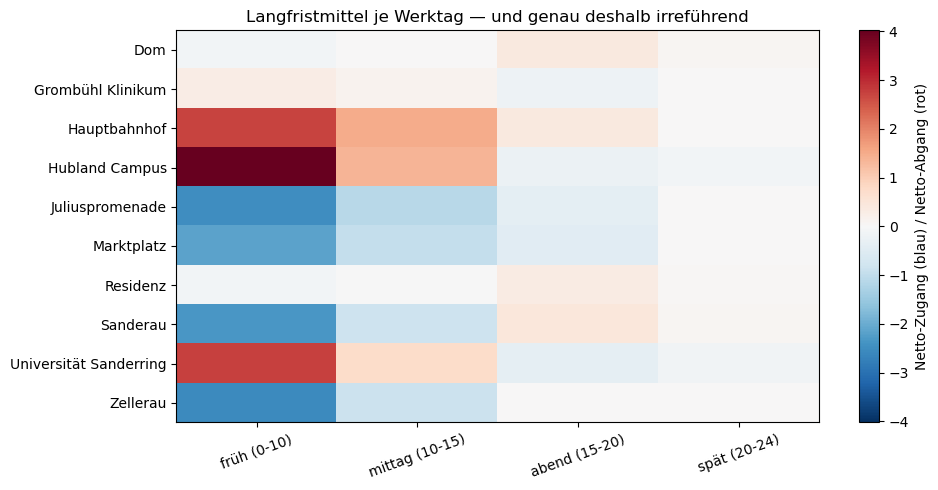

(A) DER MITTELWERT — Netto-Saldo je Werktag, über alle Werktage gemittelt:
fenster                 früh (0-10)  mittag (10-15)  abend (15-20)  spät (20-24)
station                                                                         
Dom                           -0.10            0.03           0.39          0.07
Grombühl Klinikum              0.29            0.14          -0.19          0.00
Hauptbahnhof                   2.73            1.49           0.40          0.01
Hubland Campus                 4.02            1.36          -0.23         -0.11
Juliuspromenade               -2.51           -1.11          -0.38          0.02
Marktplatz                    -2.16           -0.97          -0.45          0.01
Residenz                      -0.11           -0.01           0.34          0.05
Sanderau                      -2.35           -0.82           0.47          0.08
Universität Sanderring         2.75            0.75          -0.36         -0.13
Zellerau                      -2.5

In [11]:
# ZWEI VERSCHIEDENE AUFGABEN, GETRENNT GERECHNET
#
# (1) UMVERTEILEN zwischen Stationen: dafuer zaehlen nur Fahrten, die an
#     einer Station enden - nur sie verschieben Raeder von A nach B.
# (2) EINSAMMELN der frei abgestellten Raeder: sie verlassen ihre Station und
#     kommen an keiner anderen an. Wuerde man beides in eine Tabelle werfen,
#     stuende ueberall "auffuellen" - und die Zeile "abholen bei: frei
#     abgestellt" waere als Anweisung sinnlos.
angedockte_koerbe = KOERBE_ALLE[KOERBE_ALLE.ziel != "frei abgestellt"]

ab = angedockte_koerbe.groupby(["tagesart", "fenster", "start"], observed=True).size().rename("ab")
zu = angedockte_koerbe.groupby(["tagesart", "fenster", "ziel"], observed=True).size().rename("zu")
# nullen-sind-echt: Eine Station ohne Abfahrten hat null Abfahrten. Der
# fehlende Eintrag ist das Ereignis, nicht seine Abwesenheit im Datensatz.
saldo = pd.concat([ab, zu], axis=1).fillna(0)
saldo.index.names = ["tagesart", "fenster", "station"]
saldo["netto"] = saldo.zu - saldo.ab

# JE WERKTAG, NICHT ueber drei Jahre summiert.
#
# Eine frühere Fassung druckte hier die Rohsummen - "+1205 Raeder laufen
# auf" am Hubland. Das liest sich wie eine Anweisung an den Transporter
# und ist in Wirklichkeit die Summe ueber alle Werktage des Datensatzes.
WERKTAGE = KOERBE_ALLE[KOERBE_ALLE.tagesart == "Werktag"].startzeit.dt.date.nunique()
print(f"Der Datensatz enthält {WERKTAGE} verschiedene Werktage.\n")

werktag = saldo.loc["Werktag"].reset_index()
# nullen-sind-echt: Fenster ohne Bewegung haben Saldo null.
tabelle_gesamt = werktag.pivot(index="station", columns="fenster", values="netto").fillna(0)
tabelle = (tabelle_gesamt / WERKTAGE).round(2)

# ---------------------------------------------------------------------
# ZWEI SICHTWEISEN AUF DIESELBEN DATEN - UND NUR EINE TAUGT ALS PLAN.
#
# Der Mittelwert oben ist ein VORZEICHENBEHAFTETER Langfristmittelwert.
# Ein Tag mit +6 und ein Tag mit -6 ergeben darin 0 - und aus "0" liest
# man "nichts zu tun", obwohl an beiden Tagen sechs Raeder zu bewegen
# waren. Der Transporter faehrt aber an einzelnen Tagen, nicht im Mittel.
#
# Deshalb rechnen wir den Saldo JE TAG und sehen uns die Verteilung an.
# ---------------------------------------------------------------------
ang_werktag = angedockte_koerbe[angedockte_koerbe.tagesart == "Werktag"].copy()
ang_werktag["datum"] = ang_werktag.startzeit.dt.normalize()

ab_t = ang_werktag.groupby(["datum", "fenster", "start"], observed=True).size().rename("ab")
zu_t = ang_werktag.groupby(["datum", "fenster", "ziel"], observed=True).size().rename("zu")
# nullen-sind-echt: siehe oben - kein Eintrag heisst keine Bewegung.
je_tag = pd.concat([ab_t, zu_t], axis=1).fillna(0)
je_tag.index.names = ["datum", "fenster", "station"]
je_tag["netto"] = je_tag.zu - je_tag.ab

# Brutto-Ungleichgewicht: wieviele Raeder muessten an diesem Tag in diesem
# Fenster bewegt werden, um alle Stationen auszugleichen? Das ist die Summe
# der Ueberschuesse - jedes ueberzaehlige Rad muss genau einmal gefahren
# werden. Vorzeichen heben sich hier NICHT auf.
bedarf = je_tag.groupby(["datum", "fenster"], observed=True).netto.apply(
    lambda x: x[x > 0].sum())
bedarf_tag = bedarf.groupby("datum").sum()

# WAS DIESE SUMME IST - UND WAS SIE NICHT IST.
#
# bedarf_tag addiert vier Fensterwerte. Das entspricht der Annahme, dass
# nach JEDEM Fenster vollstaendig ausgeglichen wird. Wer nur einmal am Tag
# faehrt, gleicht weniger aus: Bewegungen am Nachmittag heben Salden vom
# Vormittag teilweise wieder auf.
#
# Beide Zahlen sind richtig gerechnet und beantworten verschiedene Fragen.
# Keine von beiden ist ein Transportbedarf - dazu fehlen Anfangsbestand,
# Kapazitaet und Eingriffszeitpunkt.
ab_t2 = ang_werktag.groupby(["datum", "start"], observed=True).size().rename("ab")
zu_t2 = ang_werktag.groupby(["datum", "ziel"], observed=True).size().rename("zu")
# nullen-sind-echt: dasselbe am Tagesende.
tagesende = pd.concat([ab_t2, zu_t2], axis=1).fillna(0)
tagesende["netto"] = tagesende.zu - tagesende.ab
rest_tag = tagesende.groupby(level=0).netto.apply(lambda x: x[x > 0].sum())

frei_werktag = None  # wird in der naechsten Zelle geografisch gebildet

plt.figure(figsize=(10, 5))
plt.imshow(tabelle.values, cmap="RdBu_r", aspect="auto",
           vmin=-abs(tabelle.values).max(), vmax=abs(tabelle.values).max())
plt.colorbar(label="Netto-Zugang (blau) / Netto-Abgang (rot)")
plt.xticks(range(len(tabelle.columns)), tabelle.columns, rotation=20)
plt.yticks(range(len(tabelle.index)), tabelle.index)
plt.title("Langfristmittel je Werktag — und genau deshalb irreführend")
plt.tight_layout(); plt.show()

print("(A) DER MITTELWERT — Netto-Saldo je Werktag, über alle Werktage gemittelt:")
print(tabelle.to_string())
merke("saldo_max", float(tabelle.values.max()))
merke("saldo_min", float(tabelle.values.min()))
merke("kap_min", int(stationen.kapazitaet.min()))
merke("kap_max", int(stationen.kapazitaet.max()))
print(f"\n    Größter Überschuss: {tabelle.values.max():.2f} Räder je Werktag")
print(f"    Größter Fehlbestand: {tabelle.values.min():.2f} Räder je Werktag")
print(f"    Zum Vergleich: die Stationen fassen {stationen.kapazitaet.min()} "
      f"bis {stationen.kapazitaet.max()} Räder.")
print("\n    Gelesen als Betriebsanweisung heisst das: nichts zu tun.")

print("\n" + "=" * 66)
print("(B) DAS THEORETISCHE NETTO-UNGLEICHGEWICHT JE WERKTAG")
print("    (wieviele Räder waeren zu bewegen, WENN vollstaendig ausgeglichen wird)\n")
print(bedarf.groupby("fenster", observed=True).agg(
    Mittel="mean", Median="median",
    P90=lambda x: x.quantile(0.9), Maximum="max").round(1).to_string())
print("\n    ZWEI AGGREGATIONEN, ZWEI FRAGEN:\n")
merke("bedarf_mittel", bedarf_tag.mean()); merke("bedarf_median", bedarf_tag.median())
merke("bedarf_p90", bedarf_tag.quantile(0.9)); merke("bedarf_max", bedarf_tag.max())
merke("rest_mittel", rest_tag.mean())
print(f"    (a) Summe der vier Fenster - Ausgleich NACH JEDEM Fenster:")
print(f"        Mittel {bedarf_tag.mean():.2f}   Median {bedarf_tag.median():.0f}   "
      f"P90 {bedarf_tag.quantile(0.9):.0f}   Maximum {bedarf_tag.max():.0f}")
print(f"    (b) nur das Ungleichgewicht am TAGESENDE - Ausgleich einmal taeglich:")
print(f"        Mittel {rest_tag.mean():.2f}   Median {rest_tag.median():.0f}   "
      f"P90 {rest_tag.quantile(0.9):.0f}   Maximum {rest_tag.max():.0f}")
print("\n    Die Aggregationsregel allein aendert den Wert um rund die Haelfte.")
print("    Welche gilt, entscheidet der Eingriffszeitpunkt - nicht die Statistik.")

# NULLTAGE GEHOEREN DAZU.
#
# je_tag enthaelt nur Tage, an denen eine Station ueberhaupt vorkam. Fuer
# Hubland Campus frueh sind das 647 der 741 Werktage. Mittelt man nur
# darueber, kommt +1,86 heraus - waehrend Tabelle (A) daneben +1,63 zeigt.
# Zwei Zahlen fuer dieselbe Groesse im selben Notebook, und der Unterschied
# sind allein die fehlenden Nullen.
ALLE_WERKTAGE = sorted(ang_werktag.datum.unique())
bsp = (je_tag.netto.xs("Hubland Campus", level="station")
       .xs("früh (0-10)", level="fenster").reindex(ALLE_WERKTAGE, fill_value=0))
print(f"\n    Beispiel Hubland Campus, früh (alle {len(bsp)} Werktage):")
merke("bsp_spanne_min", float(bsp.min())); merke("bsp_spanne_max", float(bsp.max()))
print(f"      Langfristmittel {bsp.mean():+.2f} Räder — Spanne der einzelnen Tage "
      f"{bsp.min():+.0f} bis {bsp.max():+.0f}")
print(f"      An {(bsp.abs() >= 5).mean():.0%} der Werktage weicht der Tagessaldo um "
      f"5 oder mehr Räder ab.")

# Der Nennerfehler, um den es im Text geht - hier gerechnet statt behauptet.
_mit_vorkommen = int((bsp != 0).sum())
merke("bsp_werktage", len(bsp)); merke("bsp_mit_vorkommen", _mit_vorkommen)
merke("bsp_ohne_vorkommen", len(bsp) - _mit_vorkommen)
merke("bsp_mittel_alle", bsp.mean())
merke("bsp_mittel_teil", bsp[bsp != 0].mean())
print(f"\n      NENNERPROBE: an {_mit_vorkommen} der {len(bsp)} Werktage kam die")
print(f"      Station ueberhaupt vor. Nur ueber diese gemittelt: "
      f"{bsp[bsp != 0].mean():+.2f} Raeder,")
print(f"      ueber alle {len(bsp)}: {bsp.mean():+.2f}. Die Differenz sind die "
      f"{len(bsp) - _mit_vorkommen} Tage")
print("      mit Saldo null - keine fehlenden Daten, sondern ruhige Tage.")

In [12]:
# Das vollstaendige Raster: jede Station, jedes Fenster, jeder Werktag.
# Ohne diesen Schritt fehlen Tage, an denen eine Station gar nicht vorkam -
# und genau die sind die Nullen, die den Median nach oben ziehen wuerden.
raster = pd.MultiIndex.from_product(
    [sorted(ang_werktag.datum.unique()), BEZEICHNUNGEN, sorted(tabelle.index)],
    names=["datum", "fenster", "station"])
netto_voll = je_tag.netto.reindex(raster, fill_value=0)

kennzahl = netto_voll.groupby(["fenster", "station"], observed=True).agg(
    Median="median",
    P10=lambda x: x.quantile(0.10),
    P90=lambda x: x.quantile(0.90),
    Tage_minus=lambda x: (x < 0).mean(),
    Tage_plus=lambda x: (x > 0).mean(),
    Tage_ab_5=lambda x: (x.abs() >= 5).mean())

print("EXPLORATIVE STATIONSSALDEN NACH ZEITFENSTER\n")
print("Aus den Tagessalden, nicht aus dem Mittelwert. Kein Einsatzplan:")
print("es fehlen Datum, Bestand, Kapazitaet und Entscheidungskriterium.\n")
for fenster in BEZEICHNUNGEN:
    teil = kennzahl.loc[fenster].sort_values("Median", ascending=False)
    auffaellig = teil[(teil.P90 >= 3) | (teil.P10 <= -3)]
    if auffaellig.empty:
        continue
    print(f"{fenster}")
    for station, z in auffaellig.iterrows():
        # KEINE RICHTUNG AUS EINEM MEDIAN VON NULL.
        #
        # Eine fruehere Fassung schrieb  richtung = "abholen" if Median >= 0.
        # Damit wurde jeder Median von genau 0 zu "abholen" - auch dort, wo
        # an mehr Tagen Raeder FEHLTEN als uebrig waren. Konkrete Zahlen
        # stehen hier bewusst nicht mehr: Sie aendern sich mit jedem
        # Datenstand, und ein Kommentar wandert nicht mit.
        #
        # Die Richtung folgt jetzt aus den Tagen, nicht aus dem Median, und
        # sie darf auch offen bleiben.
        if z.Tage_minus >= 1.5 * z.Tage_plus:
            richtung = "auffüllen bei        "
        elif z.Tage_plus >= 1.5 * z.Tage_minus:
            richtung = "abholen bei          "
        else:
            richtung = "keine stabile Richtung"
        print(f"    {richtung} {station:<24s} "
              f"Tage mit Minus {z.Tage_minus:>4.0%} / mit Plus {z.Tage_plus:>4.0%}   "
              f"typische Spanne {z.P10:+.0f} bis {z.P90:+.0f}   "
              f"an {z.Tage_ab_5:.0%} der Tage ≥ 5 Räder")
    print()

print(f"Theoretisches Netto-Ungleichgewicht: im Mittel {bedarf_tag.mean():.0f} Räder "
      f"je Werktag,")
print(f"an jedem zehnten Werktag {bedarf_tag.quantile(0.9):.0f} oder mehr - bei "
      f"Ausgleich nach jedem Fenster.")

# =====================================================================
# (2) EINSAMMELN - UND ZWAR DA, WO DIE RAEDER STEHEN.
#
# Eine frühere Fassung gruppierte die frei abgestellten Raeder nach ihrer
# STARTstation. Das beantwortet die Frage "wo hat die Fahrt begonnen" -
# gefragt ist aber "wo steht das Rad jetzt". Beides faellt auseinander:
# die Fahrten haben ein Ende, und end_latitude/end_longitude sind fuer
# JEDE frei abgestellte Fahrt gefuellt. Wir ordnen jedes Rad der Station
# zu, die ihm am naechsten liegt.
# =====================================================================
frei = KOERBE_ALLE[(KOERBE_ALLE.tagesart == "Werktag") & (KOERBE_ALLE.ziel == "frei abgestellt")].copy()
fehlend = frei[["end_latitude", "end_longitude"]].isna().any(axis=1).sum()
merke("frei_werktags", len(frei)); merke("frei_ohne_koordinate", int(fehlend))
print(f"\nFrei abgestellte Fahrten werktags: {len(frei)}, "
      f"davon ohne Endkoordinate: {fehlend}")

def entfernungen_km(punkt_lat, punkt_lon, st_lat, st_lon):
    """Luftlinie in Kilometern, Haversine - eine Zeile Kugelgeometrie."""
    R = 6371.0
    p1 = np.radians(punkt_lat)[:, None]; p2 = np.radians(st_lat)[None, :]
    dphi = p2 - p1
    dlam = np.radians(st_lon)[None, :] - np.radians(punkt_lon)[:, None]
    return 2 * R * np.arcsin(np.sqrt(
        np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2))

D = entfernungen_km(frei.end_latitude.values, frei.end_longitude.values,
                    stationen.latitude.values, stationen.longitude.values)
frei["nächste_station"] = stationen.name.values[D.argmin(axis=1)]
frei["abstand_km"] = D.min(axis=1)

# Die Gegenprobe: wie weit ist der Abstellort von der STARTstation entfernt?
start_index = {n: i for i, n in enumerate(stationen.name)}
zeile = np.arange(len(frei))
spalte = frei.start.map(start_index).values
abstand_start = D[zeile, spalte]

print(f"Abstand zum Abstellort ...")
print(f"   ... von der nächsten Station:  Median {np.median(frei.abstand_km):.2f} km, "
      f"P90 {np.quantile(frei.abstand_km, .9):.2f} km")
print(f"   ... von der Startstation:      Median {np.median(abstand_start):.2f} km, "
      f"P90 {np.quantile(abstand_start, .9):.2f} km")
merke("andere_station", (frei['nächste_station'] != frei.start).mean())
# JEDE ZAHL, DIE SPAETER IM TEXT STEHT, WIRD HIER FESTGEHALTEN.
#
# Der Fliesstext nannte frueher 0,30 / 0,58 / 1,27 / 3,03 km und 87,1 % -
# Werte eines aelteren Datenstands, die stehen blieben, als die Rechnung
# sich aenderte. Wer eine Zahl abtippt, baut eine zweite Quelle.
merke("frei_naechste_median", float(np.median(frei.abstand_km)))
merke("frei_naechste_p90", float(np.quantile(frei.abstand_km, .9)))
merke("frei_start_median", float(np.median(abstand_start)))
merke("frei_start_p90", float(np.quantile(abstand_start, .9)))
print(f"   Anteil, bei dem die nächste Station NICHT die Startstation ist: "
      f"{(frei['nächste_station'] != frei.start).mean():.1%}")

# FAHRTEREIGNIS IST NICHT GLEICH RAD.
#
# Was hier gezaehlt wird, sind FAHRTEN, die frei enden - nicht Raeder, die
# frei stehen. Dasselbe Rad kann an einem Tag mehrfach frei abgestellt
# werden, und ein Rad, das morgens frei endet, kann mittags laengst wieder
# unterwegs sein. Der gleichzeitig offene Bestand zu einem Einsatzzeitpunkt
# steht in diesen Daten NICHT.
frei["datum"] = frei.startzeit.dt.normalize()
# Auch hier: die Tage OHNE freies Ende gehoeren in den Nenner. Es sind 11
# von 741; wer sie weglaesst, rechnet 10,84 statt 10,68.
ereignisse_tag = frei.groupby("datum").size().reindex(ALLE_WERKTAGE, fill_value=0)
raeder_tag = (frei.groupby("datum").fahrrad_id.nunique()
              .reindex(ALLE_WERKTAGE, fill_value=0))
print(f"\nJe Werktag: {ereignisse_tag.mean():.2f} frei endende FAHRTEN, aber nur "
      f"{raeder_tag.mean():.2f} verschiedene RAEDER.")
_mehrfach = int((ereignisse_tag > raeder_tag).sum())
merke("tage_mehrfach", _mehrfach)
print(f"An {_mehrfach} Tagen kommt mindestens ein Rad mehrfach vor.")
print("Der Unterschied ist hier klein - die Einheit bleibt trotzdem wichtig.")

merke("frei_fahrten_tag", float(ereignisse_tag.mean()))
merke("frei_raeder_tag", float(raeder_tag.mean()))

einsammeln = (frei.groupby(["nächste_station", "fenster"], observed=True).size()
              .unstack(fill_value=0).reindex(columns=BEZEICHNUNGEN, fill_value=0)
              / WERKTAGE).round(2)
nach_start = (frei.groupby(["start", "fenster"], observed=True).size()
              .unstack(fill_value=0).reindex(columns=BEZEICHNUNGEN, fill_value=0)
              / WERKTAGE).round(2)

print(f"\nHISTORISCHE ABSTELL-HOTSPOTS — frei endende Fahrten je Werktag,")
print("gruppiert nach der jeweils nächsten Station. Das zeigt räumlich-zeitliche")
print("Häufungen der Vergangenheit; eine Route und ein Einsatzzeitpunkt folgen")
print("daraus nicht.")
print(einsammeln.to_string())
print(f"\ninsgesamt {len(frei) / WERKTAGE:.1f} frei endende FAHRTEREIGNISSE je Werktag")
print(f"(von {raeder_tag.mean():.1f} verschiedenen Raedern - dieselbe Unterscheidung")
print("wie oben. Die Tabelle zaehlt Ereignisse, nicht Fahrzeuge.)")

print(f"\nZum Vergleich die alte, falsche Gruppierung nach Startstation:")
print(nach_start.sum(axis=1).sort_values(ascending=False).head(3).round(2).to_string())
print("gegen die richtige nach Abstellort:")
print(einsammeln.sum(axis=1).sort_values(ascending=False).head(3).round(2).to_string())
print("Die drei Schwerpunkte sind andere - die historischen Haeufungen waeren")
print("also an den falschen Stellen verortet worden.")
# Auch die NAMEN kommen aus der Rechnung. Frueher standen im Text
# "Residenz, Universitaet Sanderring und Hauptbahnhof" - die Namen der
# falschen Gruppierung, dazu von einem aelteren Stand.
_top_ab = list(einsammeln.sum(axis=1).sort_values(ascending=False).head(3).index)
_top_start = list(nach_start.sum(axis=1).sort_values(ascending=False).head(3).index)
merke("hotspots_abstellort", ", ".join(_top_ab))
merke("hotspots_startstation", ", ".join(_top_start))

# EXPORTE MIT KOPFZEILEN - Zeitraum, Einheit, Status.
#
# Eine CSV-Datei ohne diese Angaben wird frueher oder spaeter als
# Betriebsanweisung gelesen. "umlaufplan" heisst das erste hier bewusst
# NICHT mehr: Ein Plan braucht Datum, Menge, Quelle, Ziel und ein
# Entscheidungskriterium - nichts davon steht drin.
# JEDE DATEI IHRE EIGENE EINHEIT.
#
# Eine gemeinsame Kopfzeile "Raeder je Werktag" war fuer die Hotspots
# falsch: dort stehen frei endende FAHRTEREIGNISSE, nicht Fahrzeuge. Eine
# Einheit, die fuer zwei Dateien gleichzeitig gelten soll, gilt meist fuer
# keine von beiden genau.
def kopf_fuer(einheit):
    return [
        # DER ZEITRAUM DER DATEI, NICHT DER DER REGELSUCHE.
        #
        # Hier stand koerbe - also der Entdeckungszeitraum. Gerechnet
        # sind die Salden und Hotspots aber ueber ALLE Werktage. Die
        # Kopfzeile behauptete damit einen Zeitraum, der zu den Zahlen
        # darunter nicht passte.
        f"# Analysezeitraum: {KOERBE_ALLE.startzeit.min().date()} bis "
        f"{KOERBE_ALLE.startzeit.max().date()} ({WERKTAGE} Werktage)",
        f"# Einheit: {einheit}",
        "# Datenherkunft: SYNTHETISCHE LEHRDATEN",
        "# Status: EXPLORATIV - nicht freigegeben, kein Einsatzplan",
        "# Gueltigkeit: keine - historische Auswertung ohne Einsatzdatum",
    ]

for datei, tabelle, einheit in [
        ("stationssalden_werktag.csv", kennzahl.round(2),
         f"Netto-Radbewegungen je Werktag; Verteilungskennzahlen ueber alle "
         f"{WERKTAGE} Werktage"),
        ("abstell_hotspots_werktag.csv", einsammeln,
         f"frei endende FAHRTEREIGNISSE je Werktag; historische Mittelwerte "
         f"ueber alle {WERKTAGE} Werktage")]:
    with open(datei, "w", encoding="utf-8") as f:
        f.write("\n".join(kopf_fuer(einheit)) + "\n")
        tabelle.to_csv(f)
print()
print("geschrieben: stationssalden_werktag.csv, abstell_hotspots_werktag.csv")

# ─── PRODUKT B: NUR BESTAETIGTE REGELN, UND ALS EIGENES ARTEFAKT ────
#
# Hier stand ein Freigabefehler, und er ist typisch genug, um ihn stehen
# zu lassen: B1 galt frueher als bestanden, sobald IRGENDEINE der elf
# Regeln im Bestaetigungszeitraum hielt. Damit haette das Produkt
# freigegeben werden koennen, waehrend die tatsaechlich angezeigten
# Regeln unbestaetigt sind.
#
# Ein Gate muss auf der Einheit liegen, die ausgeliefert wird. Also:
# JEDE angezeigte Regel muss ihre eigene Bestaetigung haben.
# ─── B1, GENAU WIE IN PHASE 3 FESTGELEGT ────────────────────────────
#
# Die Regel steht bei den uebrigen Kriterien, VOR dem Oeffnen dieses
# Zeitraums. Hier wird sie nur angewandt - und zwar auf ALLE im
# Entdeckungszeitraum gewaehlten Regeln, nicht nur auf die, deren
# Punktschaetzer schon ueber der Schwelle liegt. Sonst entschiede der
# Punktschaetzer doch wieder mit.
_rng_b = np.random.default_rng(20260902)
_tage_b = bestaetigung.startzeit.dt.normalize()
_nach_tag_b = {t: g for t, g in bestaetigung.groupby(_tage_b)}
_tage_liste_b = list(_nach_tag_b)

def lift_bootstrap(kontext, start, ziel, ziehungen=B1_ZIEHUNGEN):
    # Ganze Tage mit Zuruecklegen - ein Tag geht komplett hinein oder gar
    # nicht. Zurueck kommt die untere Grenze des 95-%-Bereichs.
    _art, _fen = str(kontext).split(" · ")
    _werte = []
    for _ in range(ziehungen):
        _wahl = _rng_b.choice(len(_tage_liste_b), size=len(_tage_liste_b), replace=True)
        _stich = pd.concat([_nach_tag_b[_tage_liste_b[i]] for i in _wahl])
        _raum = _stich[(_stich.tagesart == _art) & (_stich.fenster == _fen)]
        if not len(_raum):
            continue
        _ab = _raum[_raum.start == start]
        _basis = (_raum.ziel == ziel).mean()
        if not len(_ab) or _basis == 0:
            continue
        _werte.append(((_ab.ziel == ziel).mean()) / _basis)
    if len(_werte) < 20:
        return float("nan")
    return float(np.quantile(_werte, B1_NIVEAU))

print("\nB1 - JEDE REGEL EINZELN, MIT TAGESBLOCK-BOOTSTRAP")
print(f"   {B1_ZIEHUNGEN} Ziehungen ganzer Tage aus dem Bestaetigungszeitraum.")
print(f"   Verlangt: untere 95-%-Grenze >= {K2_LIFT}\n")
_kandidaten_b1 = zusammen[zusammen[f"{LIFT} bestätigt"].notna()].copy()
# Spalten ueber ihre NAMEN ansprechen, nicht ueber Positionen. Eine
# fruehere Fassung nahm _z._5 und druckte damit den Support statt des
# Lifts - Positionszugriffe verschieben sich, sobald eine Spalte
# dazukommt.
_untergrenzen = []
for _, _z in _kandidaten_b1.iterrows():
    _untergrenzen.append(lift_bootstrap(_z["Kontext"], _z["wenn Start"],
                                        _z["dann Ziel"]))
_kandidaten_b1["lift_untergrenze"] = _untergrenzen
_kandidaten_b1["b1_haelt"] = _kandidaten_b1.lift_untergrenze >= K2_LIFT

print(f"   {'Kontext':<26s}{'Start -> Ziel':<40s}{'Punkt':>7s}{'Unten':>8s}   Urteil")
for _, _z in _kandidaten_b1.iterrows():
    _weg = f"{_z['wenn Start']} -> {_z['dann Ziel']}"
    print(f"   {str(_z['Kontext']):<26s}{_weg:<40s}"
          f"{_z[f'{LIFT} bestätigt']:>7.2f}{_z['lift_untergrenze']:>8.2f}   "
          f"{'haelt' if _z['b1_haelt'] else 'HAELT NICHT'}")

b_regeln = _kandidaten_b1[_kandidaten_b1.b1_haelt].copy()
print()
_raus = _kandidaten_b1[~_kandidaten_b1.b1_haelt]
_punkt_raus = int((_raus[f"{LIFT} bestätigt"] < K2_LIFT).sum())
_ohne_grenze = int(_raus.lift_untergrenze.isna().sum())
_intervall_raus = len(_raus) - _punkt_raus - _ohne_grenze
print(f"   {len(b_regeln)} von {len(_kandidaten_b1)} Regeln halten B1 unter Unsicherheit.")
print(f"   Von den {len(_raus)} ausgeschlossenen scheitern {_punkt_raus} schon am")
print(f"   Punktschaetzer (Lift < {K2_LIFT}) - fuer sie braucht es den Bootstrap")
print(f"   gar nicht. {_intervall_raus} liegen im Punktschaetzer ueber der Schwelle,")
print("   aber ihr Intervall reicht darunter: Genau diese Gruppe zeigt den")
print("   Unterschied zwischen 'beobachtet' und 'bestaetigt'.")
if _ohne_grenze:
    print(f"   {_ohne_grenze} lassen sich nicht bewerten - zu wenige Ziehungen")
    print("   mit belegtem Kontext. Nicht bewertbar heisst nicht bestanden.")
merke("b1_kandidaten", len(_kandidaten_b1))
merke("b1_gehalten", len(b_regeln))
merke("b1_raus_punkt", _punkt_raus)
merke("b1_raus_intervall", _intervall_raus)
merke("b1_ziehungen", B1_ZIEHUNGEN)

# ─── DIE GROESSENORDNUNG - ZAEHLER UND NENNER AUS DEMSELBEN ZEITRAUM ─
#
# Hier stand ein Nennerfehler, und er ist der haeufigste ueberhaupt: Der
# Zaehler kam aus dem ENTDECKUNGSzeitraum (dem ersten Drittel), geteilt
# wurde aber durch die Werktage des GESAMTEN Datensatzes. Die angezeigte
# Groessenordnung war damit um rund den Faktor drei zu klein - und B2
# wurde eingefuehrt, damit die Disposition die Groesse nicht falsch
# einschaetzt.
#
# Gerechnet wird jetzt auf dem BESTAETIGUNGSzeitraum: Das ist der
# Zeitraum, auf den sich die ausgewiesene Evidenz bezieht, und der
# juengste dazu.
#
# UND DER RICHTIGE TAGESNENNER JE KONTEXT. Eine Regel im Kontext
# "frei · abend" betrifft keine Werktage. Sie durch Werktage zu teilen
# waere derselbe Fehler noch einmal, nur kleiner.
_tage_je_art = (bestaetigung.groupby("tagesart").startzeit.apply(
    lambda s: s.dt.date.nunique()).to_dict())
_fahrten_best = r_best.set_index(schluessel).Fahrten

def _tagesart(kontext):
    return str(kontext).split(" · ")[0]

def _je_tag(zeile):
    _art = _tagesart(zeile.Kontext)
    _n = _tage_je_art.get(_art, 0)
    _f = _fahrten_best.get((zeile.Kontext, zeile._2, zeile._3), 0)
    return round(_f / _n, 2) if _n else float("nan")

b_regeln["fahrten_je_tag"] = [_je_tag(z) for z in b_regeln.itertuples()]
b_regeln["tagesart"] = [_tagesart(k) for k in b_regeln.Kontext]
b_regeln["tage_im_nenner"] = [_tage_je_art.get(a, 0) for a in b_regeln.tagesart]
b_regeln["status"] = "Hinweis - keine automatische Aktion"
# EVIDENZZEITRAUM IST KEINE GUELTIGKEIT.
#
# Frueher hiessen diese beiden Felder gueltig_von/gueltig_bis. Damit war
# ein heute erzeugtes Artefakt laut eigener Datei schon abgelaufen -
# derselbe Fehler, den Notebook 1 an seinem Modellpaket hatte.
b_regeln["bestaetigungszeitraum_von"] = str(bestaetigung.startzeit.min().date())
b_regeln["bestaetigungszeitraum_bis"] = str(bestaetigung.startzeit.max().date())
b_regeln["gebaut_am"] = str(pd.Timestamp.today().date())
# KEINE OPERATIVE GUELTIGKEIT AUF ERFUNDENEN DATEN.
#
# Ein Gueltigkeitsdatum sagt: Bis dahin darf danach gehandelt werden.
# Das kann eine Auswertung auf synthetischen Lehrdaten nicht zusagen -
# egal wie sauber sie gerechnet ist. Was das Feld tragen darf, ist der
# Zeitraum, aus dem die EVIDENZ stammt.
# Der Hinweis gehoert in den Dateikopf, nicht in jede Zeile: Eine
# Spalte, die in jeder Zeile dasselbe sagt, ist keine Eigenschaft der
# Zeile - und unser Pruefer meldet zu Recht einen "Status ohne Wirkung".

DISPOKOPF = [
    f"# Produkt B: Dispositionshinweis, gebaut am {pd.Timestamp.today().date()}",
    f"# Evidenz aus dem Bestaetigungszeitraum "
    f"{bestaetigung.startzeit.min().date()} bis {bestaetigung.startzeit.max().date()}",
    "# KEINE AUTOMATISCHE AKTION - ein Mensch entscheidet, ob gefahren wird.",
    "# Jede Zeile ist im Bestaetigungszeitraum einzeln bestaetigt: "
    f"untere 95-%-Grenze eines Tagesblock-Bootstraps >= {K2_LIFT}",
    f"# (nicht blosser Punktschaetzer >= {K2_LIFT} - der liesse "
    f"{len(_kandidaten_b1) - _punkt_raus} Regeln zu statt {len(b_regeln)}).",
    "# Datenherkunft: SYNTHETISCHE LEHRDATEN",
    "# KEINE reale Betriebsfreigabe - Lehrbeispiel. Es gibt bewusst kein",
    "# Gueltigkeitsdatum: Was hier bestanden ist, ist ein analytisches",
    "# Lehr-Gate, keine Zusage, nach der jemand handeln darf.",
]
with open("dispositionshinweise.csv", "w", encoding="utf-8") as _f:
    _f.write(chr(10).join(DISPOKOPF) + chr(10))
    b_regeln.to_csv(_f, index=False)

print("\nPRODUKT B - DAS ARTEFAKT, DAS TATSAECHLICH AUSGELIEFERT WIRD\n")
print(f"   von {len(zusammen)} entdeckten Regeln sind {len(b_regeln)} einzeln bestaetigt")
if len(b_regeln):
    _zeig = b_regeln[schluessel + [f"{LIFT} entdeckt", f"{LIFT} bestätigt",
                                   "fahrten_je_tag", "tage_im_nenner"]]
    print(_zeig.round(2).to_string(index=False))
print(f"\n   geschrieben: dispositionshinweise.csv ({len(b_regeln)} Zeilen)")
merke("b_regeln_n", len(b_regeln))
merke("b_je_tag_max", float(b_regeln.fahrten_je_tag.max()) if len(b_regeln) else 0.0)
merke("b_zeitraum_von", str(bestaetigung.startzeit.min().date()))
merke("b_zeitraum_bis", str(bestaetigung.startzeit.max().date()))

# ─── B1 BIS B4, AM ARTEFAKT GEPRUEFT ────────────────────────────────
#
# Frueher standen hier drei Konstanten True. Eine Bedingung, die niemand
# pruefen kann, ist keine Bedingung.
_kopf = open("dispositionshinweise.csv", encoding="utf-8").read().split(chr(10))
_datei = pd.read_csv("dispositionshinweise.csv", skiprows=len(DISPOKOPF))     if len(b_regeln) else pd.DataFrame()

# B1 IST DIE UNTERGRENZE, NICHT DER PUNKTSCHAETZER - also wird auch sie
# geprueft. Der Punktschaetzer stand hier, weil b_regeln ohnehin nur
# Regeln mit haltender Untergrenze enthaelt; das Ergebnis war richtig,
# die Bedingung aber eine andere als die vorab definierte. Wer die
# Filterung spaeter aendert, merkt den Unterschied dann sofort.
B1_TRAEGT = bool(len(b_regeln)) and bool(
    (b_regeln.lift_untergrenze >= K2_LIFT).all())
# B2 WIRD NACHGERECHNET, NICHT ABGEHAKT.
#
# Frueher stand hier nur, ob die Spalte existiert. Eine Spalte mit
# falschen Zahlen erfuellt aber kein Kriterium - sie ist schlimmer als
# keine, weil sie Vertrauen erzeugt. Geprueft wird deshalb: Spalte da,
# Werte numerisch und nicht negativ, Nenner dokumentiert - und fuer die
# erste Zeile die Rechnung unabhaengig wiederholt.
_b2_pruefungen = []
if len(_datei):
    _b2_pruefungen.append(("Spalte vorhanden", "fahrten_je_tag" in _datei.columns))
    _b2_pruefungen.append(("Nenner dokumentiert", "tage_im_nenner" in _datei.columns))
    if all(e for _, e in _b2_pruefungen):
        _w = pd.to_numeric(_datei.fahrten_je_tag, errors="coerce")
        _b2_pruefungen.append(("numerisch", bool(_w.notna().all())))
        _b2_pruefungen.append(("nicht negativ", bool((_w >= 0).all())))
        # Gegenrechnung fuer die erste Zeile, aus den Rohdaten.
        _z0 = _datei.iloc[0]
        _art0 = str(_z0.Kontext).split(" · ")[0]
        _fen0 = str(_z0.Kontext).split(" · ")[1]
        _teil = bestaetigung[(bestaetigung.tagesart == _art0)
                             & (bestaetigung.fenster.astype(str) == _fen0)]
        _n0 = bestaetigung[bestaetigung.tagesart == _art0].startzeit.dt.date.nunique()
        _fahrten0 = len(_teil[(_teil.start == _z0["wenn Start"])
                              & (_teil.ziel == _z0["dann Ziel"])])
        _nach = round(_fahrten0 / _n0, 2) if _n0 else float("nan")
        _b2_pruefungen.append((f"nachgerechnet ({_fahrten0}/{_n0} = {_nach})",
                               abs(_nach - float(_z0.fahrten_je_tag)) < 0.01))
B2_ERFUELLT = bool(_b2_pruefungen) and all(e for _, e in _b2_pruefungen)
print()
print("   B2 im Einzelnen - am Artefakt geprueft, nicht behauptet:")
for _bez, _e in _b2_pruefungen:
    print(f"      {'ok    ' if _e else 'FEHLER'}  {_bez}")
B3_ERFUELLT = any("KEINE AUTOMATISCHE AKTION" in z for z in _kopf[:len(DISPOKOPF)])
# B4 - die Begleitauswertungen muessen "explorativ" im Kopf tragen.
B4_ERFUELLT = all(
    "EXPLORATIV" in open(_n, encoding="utf-8").readline().upper()
    or "EXPLORATIV" in "".join(open(_n, encoding="utf-8").readlines()[:6]).upper()
    for _n in ("stationssalden_werktag.csv", "abstell_hotspots_werktag.csv"))

# Die Zusicherung, die den alten Fehler unmoeglich macht.
assert not len(b_regeln) or (b_regeln[f"{LIFT} bestätigt"] >= K2_LIFT).all(), (
    "Eine unbestaetigte Regel ist im Dispositionshinweis gelandet.")

# DREI ZUSTAENDE, NICHT ZWEI.
#
# "nicht_pruefbar" ist kein hoeflicher Ausdruck fuer "gerissen". Ein
# gerissenes Gate sagt: Das Verfahren taugt nicht. Ein nicht pruefbares
# sagt: Wir wissen es nicht - und muessen Daten beschaffen, nicht das
# Verfahren verbessern. Wer beides gleich benennt, schickt das Projekt
# in die falsche Richtung.
A4_ZUSTAND = "nicht_pruefbar"
A4_TRAEGT = False        # nicht freigegeben - aber siehe A4_ZUSTAND
merke("a4_zustand", A4_ZUSTAND)
# Derselbe Zustand, einmal als Kuerzel fuer den Code und einmal so, wie
# man ihn vorliest. Im Fliesstext stand bisher das Kuerzel.
merke("a4_zustand_text", {"nicht_pruefbar": "mit diesen Daten nicht prüfbar",
                          "traegt": "wirtschaftlich tragfähig",
                          "traegt_nicht": "wirtschaftlich nicht tragfähig",
                          }.get(A4_ZUSTAND, A4_ZUSTAND))
# ─── DER STATUS, EINMAL - UND ALLES LIEST DARAUS ────────────────────
#
# Zwei Produkte aus Phase 1, zwei Urteile. B1 bis B4 sind oben AM
# ARTEFAKT geprueft, nicht behauptet. Frueher stand in Phase 5
# "freigegeben ist nichts" und in Phase 6 "freigegeben als
# Entscheidungshilfe" - zwei Saetze, ein Notebook, kein Massstab.
B_GATES = {"B1 Bestaetigungszeitraum": B1_TRAEGT,
           "B2 Groessenordnung sichtbar": B2_ERFUELLT,
           "B3 keine Automatik": B3_ERFUELLT,
           "B4 Begleitanalysen als explorativ gekennzeichnet": B4_ERFUELLT}

STATUS_A = ("freigegeben" if (len(brauchbar) > 0 and A4_TRAEGT)
            else "nicht freigegeben (Wirtschaftlichkeit nicht prüfbar)")
# KEINE BETRIEBSFREIGABE AUF SYNTHETISCHEN DATEN.
#
# "freigegeben" klingt nach einer Entscheidung, die jemand mit
# Verantwortung getroffen hat. Getroffen hat sie hier ein Notebook auf
# erfundenen Daten. Was bestanden ist, ist ein LEHR-GATE - die
# analytische Huerde, die dieses Notebook vorab definiert hat. Ob das
# Produkt in Betrieb geht, entscheidet niemand hier.
STATUS_B = ("analytisches Lehr-Gate bestanden — keine reale "
            "Betriebsfreigabe"
            if all(B_GATES.values())
            else "analytisches Lehr-Gate nicht bestanden")
STATUS_SATZ = (
    f"Produkt A (automatische Umverteilungsregel): {STATUS_A}. "
    f"Produkt B (Dispositionshinweis): {STATUS_B}."
)
merke("status_a", STATUS_A)
merke("status_b", STATUS_B)
merke("status_satz", STATUS_SATZ)

print("\nDIE ZWEI PRODUKTE AUS PHASE 1 - ein Urteil je Produkt:\n")
print(f"   Produkt A  automatische Umverteilungsregel   {STATUS_A.upper()}")
print(f"      A1-A3 (Support, Lift, Stationsziel): {len(brauchbar)} Regel(n) nehmen sie")
print(f"      A4 (wirtschaftlich): {_lohnt} von {len(brauchbar)} tragen eine "
      f"eigene Umsetzrunde  ->  {A4_ZUSTAND.upper()}")
print(f"\n   Produkt B  Dispositionshinweis               {STATUS_B.upper()}")
for _n, _e in B_GATES.items():
    print(f"      {'erfuellt' if _e else 'OFFEN   '}  {_n}")
print()
print("   Das ist kein Trostpreis, sondern eine andere Zusage: Ein Hinweis,")
print("   den ein Mensch bewertet, braucht keinen Wirtschaftlichkeitsnachweis -")
print("   er loest ja keine Fahrt aus. Ein Auftrag braucht ihn, und deshalb")
print("   entsteht keiner.")
print("Beide mit Kopfzeilen: Zeitraum, Einheit, Herkunft, Status.")
print("Die Dateien heissen bewusst nicht 'Plan' - ein Plan braucht Datum,")
print("Bestand, Menge und ein Entscheidungskriterium.")

EXPLORATIVE STATIONSSALDEN NACH ZEITFENSTER

Aus den Tagessalden, nicht aus dem Mittelwert. Kein Einsatzplan:
es fehlen Datum, Bestand, Kapazitaet und Entscheidungskriterium.

früh (0-10)
    abholen bei           Hubland Campus           Tage mit Minus   1% / mit Plus  89%   typische Spanne +0 bis +9   an 36% der Tage ≥ 5 Räder
    abholen bei           Hauptbahnhof             Tage mit Minus   3% / mit Plus  80%   typische Spanne +0 bis +6   an 23% der Tage ≥ 5 Räder
    abholen bei           Universität Sanderring   Tage mit Minus   2% / mit Plus  79%   typische Spanne +0 bis +7   an 22% der Tage ≥ 5 Räder
    keine stabile Richtung Grombühl Klinikum        Tage mit Minus  34% / mit Plus  43%   typische Spanne -2 bis +3   an 7% der Tage ≥ 5 Räder
    auffüllen bei         Juliuspromenade          Tage mit Minus  78% / mit Plus   2%   typische Spanne -6 bis +0   an 19% der Tage ≥ 5 Räder
    auffüllen bei         Marktplatz               Tage mit Minus  75% / mit Plus   4%   typische

   Kontext                   Start -> Ziel                             Punkt   Unten   Urteil
   Werktag · früh (0-10)     Grombühl Klinikum -> Hauptbahnhof          1.48    1.37   haelt
   Werktag · früh (0-10)     Juliuspromenade -> Grombühl Klinikum       1.51    1.39   haelt
   Werktag · früh (0-10)     Marktplatz -> Grombühl Klinikum            1.44    1.33   haelt
   Werktag · mittag (10-15)  Grombühl Klinikum -> Hauptbahnhof          1.68    1.52   haelt
   Werktag · mittag (10-15)  Grombühl Klinikum -> Hubland Campus        1.35    1.21   HAELT NICHT
   Werktag · mittag (10-15)  Juliuspromenade -> Grombühl Klinikum       1.55    1.40   haelt
   Werktag · abend (15-20)   Grombühl Klinikum -> Hauptbahnhof          1.58    1.45   haelt
   Werktag · abend (15-20)   Hauptbahnhof -> Sanderau                   1.24    1.07   HAELT NICHT
   Werktag · abend (15-20)   Hauptbahnhof -> Grombühl Klinikum          1.27    1.10   HAELT NICHT
   Werktag · abend (15-20)   Sanderau -> Zellerau  

### 6.1 Wahl der Kennzahl: Mittelwert oder Tagesverteilung

Tabelle (A) nennt als größten Überschuss **+4,02 Räder je Werktag** und als
größten Fehlbestand **-2,55** — bei Stationen mit 35 bis
65 Plätzen. Daraus zu schließen, für zwei Räder fahre kein Transporter,
wäre falsch. Nicht wegen der Zahlen, sondern wegen der **Wahl der Kennzahl**.

Der Mittelwert ist vorzeichenbehaftet: Ein Tag mit +6 und einer mit −6 ergeben zusammen
null. An beiden Tagen waren sechs Räder zu bewegen. **Der Transporter fährt an
einzelnen Tagen, nicht im Mittel.** Tabelle (B) rechnet deshalb den Saldo je Tag:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Räder je Werktag</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Mittel</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>25,7</strong></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Median</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">23</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">an jedem zehnten Werktag mindestens</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">46</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Maximum</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>91</strong></td></tr>
</tbody></table>
<div style="clear:both"></div>

Diese Zahl addiert die vier Zeitfenster und unterstellt vollständigen Ausgleich **nach
jedem Fenster**. Wer nur einmal täglich fährt, gleicht weniger aus; für das
Ungleichgewicht am Tagesende sind es **17,3**. Beide Werte sind richtig
gerechnet — welcher gilt, entscheidet der **Eingriffszeitpunkt**, und der ist eine
betriebliche Festlegung.

Zwischen dem Stationsmittelwert und den 25,7 liegt kein neuer Datensatz,
sondern eine andere Aggregation. Beispiel Hubland Campus: Langfristmittel
**+4,02**, einzelne Werktage von **-1 bis
+24**.

Der Nenner ist dabei entscheidend: Die Tagestabelle enthält nur Tage, an denen die
Station vorkam — für Hubland früh 1125 von 1261
Werktagen. Über diese gemittelt ergibt sich **+4,50**, über alle
**+4,02**. Die 136 fehlenden Tage sind keine
Datenlücke, sondern Tage mit Saldo null.

> **Die Regel gilt über dieses Notebook hinaus:** Enthält eine über die Zeit gemittelte
> Kennzahl positive und negative Werte, misst der Mittelwert den Trend, nicht die Arbeit.
> Für alles, was je Tag zu tun ist, braucht man die Verteilung der Tageswerte.

**Ob der Plan trägt, beantwortet dieses Notebook nicht.** Weder 25,7
noch 17,3 sind ein Transportbedarf; beides sind aus Fahrten gerechnete
Ungleichgewichte. Dazu fehlen drei Angaben:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">fehlt</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">warum es entscheidet</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Anfangsbestand</strong> je Station</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Ein Überschuss von +6 ist an einer halbvollen Station belanglos und an einer vollen ein Problem</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Kapazität</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Über der Kapazität geht nichts mehr hinein, darunter ist Luft</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Eingriffszeitpunkt</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Er entscheidet, welche der beiden Aggregationen gilt</td></tr>
</tbody></table>
<div style="clear:both"></div>

Dazu die zwei Kostengrößen, die schon der Ein-Prozent-Hürde fehlten: was eine Fahrt
kostet und was ein leerer Stationsplatz kostet. Dieselbe Lücke an zwei Stellen.

### 6.2 Stationssalden: Aussagekraft und Grenzen

Tabelle (B) gibt die **Richtung** her, und auch die nicht überall. Morgens gewinnen
Hubland Campus und Universität Sanderring Räder hinzu, während Hauptbahnhof, Sanderau,
Zellerau und Grombühl verlieren; die Spalten „Tage mit Plus" und „Tage mit Minus" nennen
die Anteile.

Mittags liegt der Fall anders. Eine Regel `abholen, wenn Median >= 0` ordnet einen Median
von genau null der Richtung „abholen" zu — auch dort, wo an mehr Tagen Räder fehlten als
übrig waren. **Ein Median von null bezeichnet keine Richtung, sondern das Fehlen einer.**
Die Richtung wird deshalb aus dem Verhältnis der Plus- und Minustage abgeleitet und darf
auch „keine stabile Richtung" lauten.

Die **Stückzahl** für einen bestimmten Morgen geben die Salden nicht her: Der Median
liegt bei ±1 Rad, die typische Spanne bei −4 bis +4, an rund jedem zehnten Werktag sind
es fünf oder mehr. Die exportierte Datei enthält deshalb die Verteilung statt einer Zahl
je Station und heißt `stationssalden_werktag.csv`, nicht `umlaufplan` — ein Plan
bräuchte Datum, Bestand, Menge und ein Entscheidungskriterium.

### 6.3 Einsammeln frei abgestellter Räder

Werktäglich enden **8,87 Fahrten** frei im Gebiet, von
**8,87 verschiedenen Rädern**. Die beiden Zahlen fallen auseinander,
sobald ein Rad an einem Tag mehrfach frei abgestellt wird; hier an
**0** Tagen. Diese Auswertung braucht keine einzige
Assoziationsregel; sie folgt aus der Auszählung.

Entscheidend ist, **wo** die Räder stehen. Eine Gruppierung nach der **Startstation**
liefert das nicht — sie ist eine Herkunfts-, keine Ortsangabe:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Median</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">an 9 von 10 Fahrten höchstens</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Abstand des Rades zur <strong>nächsten</strong> Station</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">0,33 km</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">0,50 km</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Abstand des Rades zur <strong>Start</strong>station</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1,12 km</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2,30 km</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Bei 90,6 % der frei abgestellten Räder ist die nächstgelegene Station
eine andere als die, an der die Fahrt begann.** Die Schwerpunkte verschieben sich
entsprechend: nach Abstellort **Dom, Hauptbahnhof, Grombühl Klinikum**, nach Startstation wären es
Grombühl Klinikum, Sanderau, Zellerau gewesen. `end_latitude` und `end_longitude` sind für jede der
11.188 werktäglichen frei endenden Fahrten gefüllt
(0 fehlend) — eine Ortsfrage über eine Herkunftsspalte zu
beantworten ergibt eine plausible Tabelle und einen falsch fahrenden Transporter.

### 6.4 Reichweite und Grenzen der Auswertung

Sie zeigt, **wo sich frei abgestellte Räder in der Vergangenheit gehäuft haben** und in
welchen Zeitfenstern. Sie sagt nicht, wo heute Abend welche stehen — dafür bräuchte es
Live-Positionen — und auch nicht, wie viele Räder an eine Station gehören; das war
Notebook 4. Der Unterschied zwischen „wo es sich häuft" und „wo einzusammeln ist" ist
der zwischen einer Karte und einer Route; für die Route fehlen Bestand,
Fahrzeugkapazität, Zeitfenster und Fahrtkosten.

Zwei Aufgaben sind dabei zu trennen:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom"></th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Aufgabe</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Datengrundlage</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Umverteilen</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Räder von vollen zu leeren Stationen fahren</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">nur Fahrten, die an einer Station enden</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Einsammeln</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">frei abgestellte Räder aufnehmen</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">die frei endenden Fahrten</td></tr>
</tbody></table>
<div style="clear:both"></div>

In einer gemeinsamen Tabelle stünde bei jeder Station „auffüllen", weil ein Fünftel aller
Räder das Stationsnetz verlässt. Die Zeile „abholen bei: frei abgestellt" wäre als
Anweisung wertlos.

### 6.5 Übergabe und Überwachung

**Produkt A ist nicht freigegeben (Wirtschaftlichkeit nicht prüfbar), Produkt B ist analytisches Lehr-Gate bestanden — keine reale Betriebsfreigabe.** Beide Urteile stammen aus
derselben Zelle in Phase 5, gemessen an den Kriterien aus Phase 1. Die Regeln werden als
**Dispositionshinweis** übergeben, nicht als Transportauftrag.

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Was erzeugt wird</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">dispositionshinweise.csv</code> mit den <strong>6 einzeln bestätigten Regeln</strong>, jede mit ihrer Größenordnung daneben (höchstens 1,02 Fahrten je Tag). Dazu die Stationssalden und die Abstell-Hotspots — beide ausdrücklich explorativ.</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Was damit NICHT gezeigt ist</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">dass die Datei in einer Dispositionsansicht ankommt. Geprüft wird der <strong>Export</strong>: Spalten, Nenner, Kopfzeilen. Ladeweg, Schema, Anzeige der Größenordnung und Fehlerverhalten sind ein Integrationstest, den es hier nicht gibt. Die zutreffende Formulierung lautet <strong>„für die Übergabe erzeugt"</strong>, nicht „läuft".</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Was nicht läuft</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Kein automatischer Umsetzauftrag. A4 ist <strong>mit diesen Daten nicht prüfbar</strong> — nicht widerlegt: Die Szenariorechnung zeigt höchstens 1,02 Fahrten je Tag bei angenommenen 2,20 € je Fahrt gegen 35 € je Runde. Sie ist <strong>keine Obergrenze</strong> — die Fahrten, die mangels Rad nie stattfanden, stehen nirgends in diesen Daten.</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Wofür die Evidenz gilt</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Bestätigungszeitraum 2024-12-24 bis 2026-08-24. Das ist <strong>kein Gültigkeitsdatum</strong> — und die Datei nennt auch keines. Sie trägt <code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">gebaut_am</code> und den Evidenzzeitraum: Ein Gültigkeitsdatum wäre eine Zusage, nach der jemand handeln darf, und die gibt dieses Lehr-Gate nicht her.</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>Wer entscheidet</strong></td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Die Disposition. Sie verbindet den Hinweis mit dem, was das System nicht weiß — Baustellen, Veranstaltungen, ausgefallene Fahrzeuge.</td></tr>
</tbody></table>
<div style="clear:both"></div>

Produkt B ist keine nachträgliche Umdeutung: Es steht mit vier eigenen Kriterien in
Phase 1. Wäre B1 gerissen, gäbe es auch diesen Hinweis nicht.

Überwacht wird, was tatsächlich angezeigt wird. Die Schwellen sind plausible
Diskussionswerte, nicht kalibriert:

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Wache</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Schwelle</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Reaktion</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">frei endende Fahrten je Werktag</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">weichen zwei Wochen lang um mehr als ein Drittel ab</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Nutzungsverhalten hat sich geändert — neu auszählen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Schwerpunkt-Station wechselt</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">zwei Monate in Folge</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Route anpassen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Anteil frei abgestellter Fahrten</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">steigt über 25 % oder fällt unter 15 %</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Geschäftsgebiet oder Preismodell wurde geändert</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">theoretisches Netto-Ungleichgewicht (Tabelle B)</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">P90 überschreitet 40 Räder</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Umverteilung neu bewerten</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">neue Station im Netz</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">taucht auf</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top"><strong>alles neu rechnen</strong></td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Baustelle oder Sperrung</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">gemeldet</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">betroffene Wege aussetzen, nicht nachjustieren</td></tr>
</tbody></table>
<div style="clear:both"></div>

Die vorletzte Zeile hat einen methodischen Grund: Der Lift misst gegen die Basisrate der
Ziele im Kontext. Eine elfte Station verschiebt diese Basisrate für **jede** Regel, auch
für solche ohne Bezug zur neuen Station. **Assoziationsregeln lassen sich deshalb nicht
stückweise fortschreiben**, sondern nur vollständig neu berechnen und erneut gegen die
Kriterien aus Phase 1 prüfen.

### 6.6 Datenschutz

Diese Analyse arbeitet mit **Bewegungsdaten von Personen**. Für Stationssalden und
Abstell-Hotspots werden sie nur aggregiert benötigt, und so sollten beide auch entstehen.

Die Gegenprobe in Phase 5 ist etwas anderes: Sie greift auf `kunde_id` und Datum zurück
und fragt, wer an welchem Tag welchen Weg gefahren ist. **Das ist ein Bewegungsprofil**,
auch wenn es hier der Widerlegung einer eigenen Behauptung diente. Vor einem
Regelbetrieb gehören Zweckbindung, Rechtsgrundlage und Speicherdauer geprüft. Das ist
ein **Prüfbedarf**, keine abschließende Rechtsbewertung.

---

# Zusammenfassung

<table align="left" style="border-collapse:collapse;margin:14px 0 18px 0;font-size:0.95em;line-height:1.45">
<thead><tr><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Phase</th><th style="text-align:left;padding:7px 14px 7px 0;border-bottom:2px solid #003E6E;color:#003E6E;font-weight:600;vertical-align:bottom">Ergebnis</th></tr></thead>
<tbody>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">1 Business Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">„Von wo nach wo?“ statt „wie viele?“. <strong>Zwei Produkte mit eigenen Kriterien:</strong> Produkt A (automatische Umverteilung) verlangt A1 Support ≥ 1 %, A2 kontextbedingter Lift ≥ 1,3, A3 Ziel ist eine konkrete Station <strong>und A4 Wirtschaftlichkeit</strong>; Produkt B (Dispositionshinweis) verlangt B1 Bestätigung <strong>je einzelner Regel</strong>, B2 Größenordnung neben der Regel, B3 keine Automatik, B4 Begleitanalysen als explorativ gekennzeichnet</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2 Data Understanding</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Eine Fahrt ist ein Warenkorb. Rundtouren (12,6 % der angedockten Fahrten) sind trivial und ausgeschlossen</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">3 Data Preparation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Vier Zeitfenster statt 24 Stunden, sonst wäre jede Regel unbelegt</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">4 Modeling</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Support, Konfidenz und Lift von Hand — drei Divisionen, eine davon Zeile für Zeile nachgerechnet</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">5 Evaluation</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">2 Regel(n) nehmen A1 bis A3. Die Hürde wird nicht verschoben, obwohl sie auf der falschen Skala liegt: Sie verlangt 0,66 Fahrten je Werktag. Die Pendlerdeutung hält die tagesgenaue Gegenprobe nicht aus — 1 von 410 Abendfahrten stammen von jemandem, der morgens hingefahren war</td></tr>
<tr><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">6 Deployment</td><td style="text-align:left;padding:6px 14px 6px 0;border-bottom:1px solid #E3DED1;vertical-align:top">Produkt A (automatische Umverteilungsregel): nicht freigegeben (Wirtschaftlichkeit nicht prüfbar). Produkt B (Dispositionshinweis): analytisches Lehr-Gate bestanden — keine reale Betriebsfreigabe. Erzeugt wird <code style="background:#F7F5EF;padding:1px 4px;border-radius:3px">dispositionshinweise.csv</code> mit <strong>6 einzeln bestätigten Regeln</strong> (Bootstrap-Untergrenze ≥ 1,3), jede mit Größenordnung und Nenner; dazu Stationssalden und Abstell-Hotspots, beide <strong>explorativ</strong>. Keine Automatik, weil A4 <strong>mit diesen Daten nicht prüfbar</strong> ist. Die Hotspots sind über die <strong>End</strong>koordinaten verortet; bei 90,6 % ist die nächste Station eine andere als die Startstation</td></tr>
</tbody></table>
<div style="clear:both"></div>

**Drei Ergebnisse dieses Notebooks**

1. Ein Mittelwert über Plus und Minus misst den Trend, nicht die Arbeit. Der
   Stationsmittelwert und die 25,7 Räder je Werktag sind derselbe
   Datensatz, zweimal aggregiert.
2. Ein Erfolgskriterium muss in der Einheit formuliert sein, in der es begründet wurde.
   Eine Hürde bei 0,66 Fahrten je Werktag misst betrieblich nichts —
   und darf trotzdem nicht nachträglich verschoben werden.
3. Eine Regel mit korrekten Kennzahlen kann eine falsche Deutung tragen.
   68 Personen fuhren „beide Richtungen" —
   und nur eine einzige davon am selben Tag.

**Was eine zweite Runde anders machen würde**

1. **Das Erfolgskriterium neu formulieren** — in Fahrten je Werktag, hergeleitet aus den
   Kosten einer Transporterfahrt. Diese Kosten zu beschaffen ist die erste Aufgabe.
2. **Die Bestätigung rollierend machen.** Der einmalige Schnitt aus Phase 5.3 hat
   gehalten (9 von 11 Regeln; über die vier
   aufeinanderfolgenden Teilfenster 8 bis 9 von
   11). Das sind **keine rollierenden Fenster**: Alle vier prüfen
   dieselben im ersten Drittel gefundenen Regeln. Mehrere rollierende, saisonal
   vergleichbare Fenster würden zeigen, ob die Stabilität an den Regeln liegt oder am
   Schnittpunkt.
3. **Zurück zu Phase 3:** Die vier Zeitfenster sind gesetzt, nicht gefunden. Eine
   Aufteilung nach den tatsächlichen Spitzen könnte schärfere Regeln liefern. Die
   Support-Untergrenze von 0,5 % gehört mit auf den Prüfstand — sie hat die
   zweitstärkste Verbindung aussortiert, bevor sie jemand gesehen hat.
4. **Die Richtung ernst nehmen.** In der klassischen Warenkorbanalyse sind Support und
   Lift symmetrisch. Hier nicht: Eine Fahrt vom Hauptbahnhof zum Campus und eine vom
   Campus zum Hauptbahnhof sind zwei verschiedene Ereignisse mit verschiedenen
   Häufigkeiten, Zeitfenstern und Lift-Werten — 245 Fahrten morgens
   gegen 410 abends. Und keine der drei Kennzahlen kennt ein
   *weil*.

**Weiter geht es mit Notebook 6 — Anomalieerkennung:** Dort werden nicht Muster gesucht,
sondern ihre Ausnahmen. Die schwierigste Frage lautet dabei nicht „was ist auffällig?",
sondern „was davon ist ein Problem?"